# Objetivo
Neste notebook vamos criar um modelo de anomalias usando mínimo quadrados com uma base limitada para conseguirmos ver ele entrar em drift, e submetelo a um processo de avaliação de drift e retreinamento, neste processo vamos usar mínimos quadrados ponderados no retreinamento.<br/>


## Base de Dados
Como base iremos usar a NAB (https://www.kaggle.com/datasets/boltzmannbrain/nab/data) disponivel no kaggle e no github, que contém fluxos de dados reais com anomalias, esses dados são métricas da AWS, como uso de mémoria, cpu, e dados artificiais.

In [1]:
# Usando quando executado pelo Google Colab
#from google.colab import drive
#drive.mount('/content/drive')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import ks_2samp
from scipy.interpolate import UnivariateSpline

## 01 - Leitura da base de dados

Nesta etapa, realizamos a leitura da base `nyc_taxi.csv`, pertencente ao conjunto de dados NAB. Essa base contém uma série temporal com registros do volume de tráfego de táxis em Nova York ao longo do tempo.

O objetivo inicial é carregar os dados, converter a coluna de data e hora para o formato adequado, ordenar os registros cronologicamente e padronizar os nomes das colunas para facilitar o uso em modelos de séries temporais.

A coluna `ds` representa o instante da medição, enquanto a coluna `y` representa o valor observado naquele momento.

In [3]:
df = pd.read_csv('nab/realKnownCause/realKnownCause/nyc_taxi.csv')

df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values(by='timestamp', ascending=True)

# Alteramos os nomes conforme citado acima
df.rename(columns={"timestamp": "ds", "value": "y"}, inplace=True)

df = df.reset_index(drop=True)

In [4]:
# o dataset é simples com valor e a hora do registro
df.head()

,ds,y
0,2014-07-01 00:00:00,10844
1,2014-07-01 00:30:00,8127
2,2014-07-01 01:00:00,6210
3,2014-07-01 01:30:00,4656
4,2014-07-01 02:00:00,3820


In [5]:
# Não temos valores nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10320 entries, 0 to 10319
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      10320 non-null  datetime64[us]
 1   y       10320 non-null  int64         
dtypes: datetime64[us](1), int64(1)
memory usage: 161.4 KB


In [6]:
# Temos 10320 linhas
df.shape

(10320, 2)

In [7]:
# Janela inicial e final
df.ds.min(),df.ds.max()

(Timestamp('2014-07-01 00:00:00'), Timestamp('2015-01-31 23:30:00'))

In [8]:
# valor da mediana e média
df.y.median(),df.y.mean()

(np.float64(16778.0), np.float64(15137.569379844961))

In [9]:
# desvio padrão
df.y.std()

np.float64(6939.495808067993)

### 01.1 - Criação de variáveis explicativas

Nesta etapa, são criadas variáveis derivadas da própria série temporal para que o modelo consiga aprender padrões de comportamento ao longo do tempo.

Primeiro, são criadas variáveis de defasagem, chamadas de *lags*. Essas variáveis representam os valores anteriores da série `y`. Por exemplo, `lag_1` contém o valor imediatamente anterior, `lag_2` contém o valor observado dois períodos antes, e assim sucessivamente até `lag_5`.
Essas variáveis são importantes porque, em séries temporais, o valor atual geralmente possui relação com os valores passados. Dessa forma, o modelo passa a considerar a dependência temporal da série.

In [10]:
df['lag_1'] = df['y'].shift(1)
df['lag_2'] = df['y'].shift(2)
df['lag_3'] = df['y'].shift(3)
df['lag_4'] = df['y'].shift(4)
df['lag_5'] = df['y'].shift(5)

Também é criada a variável `rolling_mean_5`, que representa a média móvel dos cinco valores anteriores. O uso de `shift(1)` antes do cálculo da média garante que o valor atual não seja utilizado na construção da própria previsão, evitando vazamento de informação.

In [11]:
df['rolling_mean_5'] = df['y'].shift(1).rolling(window=5).mean()

Além das variáveis baseadas em valores passados, são extraídas informações temporais da coluna `ds`, como a hora do dia e o dia da semana. Essas variáveis ajudam o modelo a capturar padrões sazonais, como variações ao longo do dia ou diferenças entre dias úteis e finais de semana.

In [12]:
df['hour'] = df['ds'].dt.hour
df['day_of_week'] = df['ds'].dt.dayofweek

As variáveis `hour_sin`, `hour_cos`, `dow_sin` e `dow_cos` transformam hora e dia da semana em representações cíclicas. Essa transformação é importante porque tempo possui comportamento circular: por exemplo, 23h está próximo de 0h, assim como domingo está próximo de segunda-feira. Usar seno e cosseno permite que o modelo entenda essa continuidade temporal.

In [13]:
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

In [14]:
df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

Por fim, as primeiras linhas com valores nulos são removidas, pois as variáveis defasadas e a média móvel não possuem valores disponíveis no início da série. O índice é reiniciado para manter o dataframe organizado após essa remoção.

In [15]:
df = df.dropna().reset_index(drop=True)

### 01.2 Identificando as anomalias
Nesta etapa, é criada uma análise inicial para identificar possíveis anomalias na série temporal antes do treinamento do modelo.

Primeiro, é feita uma cópia do dataframe original para preservar os dados já tratados. Em seguida, a coluna `ds`, que representa a data e hora da observação, é definida como índice do dataframe. Isso facilita operações temporais, como extração de hora, dia da semana e agrupamentos por período.

A partir do índice temporal, são criadas duas variáveis auxiliares: `hour`, que representa a hora do dia, e `day_of_week`, que representa o dia da semana. Essas informações são importantes porque o volume de táxis possui comportamento sazonal, ou seja, tende a variar conforme o horário e o dia.

Depois, é calculado um perfil esperado de comportamento para cada combinação de dia da semana e hora do dia. Esse perfil representa a média histórica do volume de táxis naquele tipo de período. Por exemplo, o modelo calcula qual costuma ser o volume médio às segundas-feiras às 8h, às terças-feiras às 14h, e assim por diante.

Com esse perfil esperado, é calculado o resíduo de cada observação. O resíduo representa a diferença entre o valor real observado e o valor médio esperado para aquele mesmo horário e dia da semana. Quando o resíduo é muito alto, significa que o valor observado ficou muito acima do comportamento típico daquele período.

Em seguida, é aplicado o Z-Score sobre os resíduos. O Z-Score mede o quanto cada resíduo se afasta da média dos resíduos em termos de desvios-padrão. Neste caso, foi definido um limite de `3`, ou seja, são consideradas anomalias as observações cujo resíduo esteja mais de três desvios-padrão acima do comportamento esperado.


In [16]:
# criar dataset para anomalias
df_anomalias = df.copy()
df_anomalias = df_anomalias.set_index('ds')

In [17]:
# 1. Criar colunas de tempo
df_anomalias['hour'] = df_anomalias.index.hour
df_anomalias['day_of_week'] = df_anomalias.index.dayofweek

In [18]:
# 2. Calcular o comportamento esperado para cada horário e dia
profile = df_anomalias.groupby(['day_of_week', 'hour'])['y'].transform('mean')

In [19]:
# 3. Calcular o resíduo entre o real e o esperado
df_anomalias['residual'] = df_anomalias['y'] - profile

In [20]:
# 4. Aplicar Z-Score no resíduo
mean_res = df_anomalias['residual'].mean()
std_res = df_anomalias['residual'].std()

A coluna `is_anomaly` indica se uma observação foi classificada como anômala. Como o foco está em detectar picos de volume, a regra considera apenas valores muito acima do esperado.

Por fim, as anomalias detectadas são separadas em um novo dataframe e visualizadas em um gráfico. A linha representa o volume observado de táxis ao longo do tempo, enquanto os pontos em vermelho destacam os momentos classificados como anomalias.

Essa etapa é importante porque cria uma referência inicial sobre eventos atípicos na série, ajudando a entender quais períodos fogem do comportamento normal antes de avaliar o drift do modelo.

In [21]:
threshold = 3
df_anomalias['z_score'] = (df_anomalias['residual'] - mean_res) / std_res
df_anomalias['is_anomaly'] = df_anomalias['z_score'] > threshold

anomalies = df_anomalias[df_anomalias['is_anomaly']]

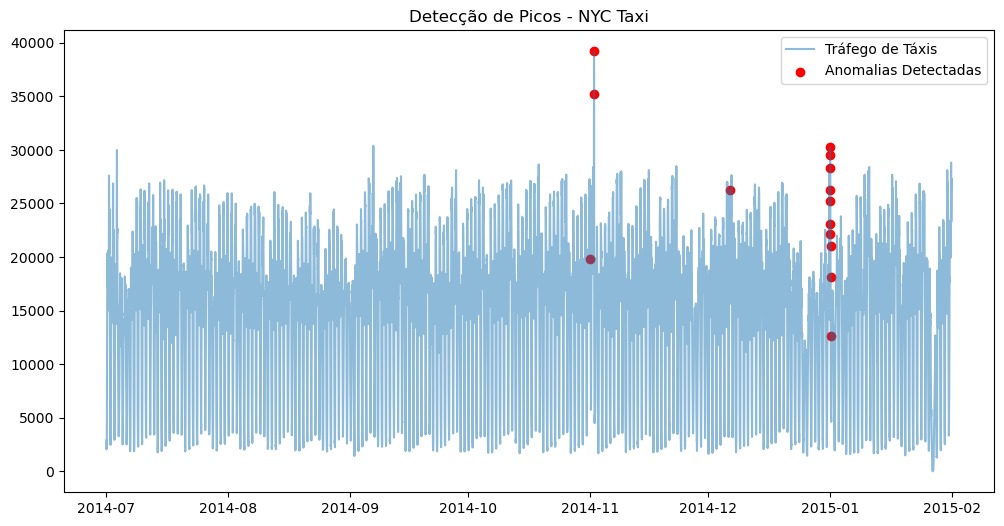

In [22]:
plt.figure(figsize=(12, 6))
plt.plot(df_anomalias.index, df_anomalias['y'], label='Tráfego de Táxis', alpha=0.5)
plt.scatter(
    anomalies.index,
    anomalies['y'],
    color='red',
    label='Anomalias Detectadas'
)
plt.title('Detecção de Picos - NYC Taxi')
plt.legend()
plt.show()

In [23]:
# Lista as datas em que foram detectadas anomalias na série temporal
set(df_anomalias[df_anomalias.is_anomaly == True].index.date)

{datetime.date(2014, 11, 1),
 datetime.date(2014, 11, 2),
 datetime.date(2014, 12, 6),
 datetime.date(2015, 1, 1)}

 - 01/11/2014 - Maratona de NYC
 - 06/12/2014 - Estavam acontecendo protestos do caso Eric Garner na época (https://g1.globo.com/jornal-nacional/noticia/2014/12/violencia-policial-manifestantes-voltam-ruas-de-cidades-americanas.html)
 - 25/12/2014 - Natal (Não localizado anomalia)
 - 01/01/2015 - Ano Novo

In [24]:
df['anomalies'] = df.ds.isin(anomalies.index)

## 02 - Treinamento do modelo 1 com mínimos quadrados

Nesta etapa, treinamos o primeiro modelo com Mínimos Quadrados Ordinários (OLS) usando uma janela inicial limitada da série temporal.  
O objetivo é criar um modelo base simples, treinado apenas com dados até `2014-08-01`, para acompanhar sua performance em dados futuros.  
A janela de calibração, entre `2014-08-01` e `2014-08-07`, é usada para calcular erros históricos, bandas de previsão e limites de controle.  
Depois disso, o modelo será aplicado em dados de stream para verificar sinais de piora de desempenho e possível drift.

In [25]:
class OrdinaryLeastSquares:
    """
    Implementação manual do modelo de Mínimos Quadrados Ordinários (OLS).

    A classe estima uma relação linear entre as variáveis explicativas X
    e a variável alvo y, resolvendo a equação normal dos mínimos quadrados.
    """

    def __init__(self, fit_intercept=True, ridge_eps=0.0):
        """
        Inicializa os parâmetros principais do modelo.

        fit_intercept:
            Define se o modelo deve incluir intercepto.

        ridge_eps:
            Valor opcional de regularização para evitar problemas de matriz singular.
        """

        # Indica se o modelo deve adicionar uma coluna de intercepto
        self.fit_intercept = fit_intercept

        # Pequeno termo de regularização opcional
        self.ridge_eps = ridge_eps

        # Coeficientes das variáveis explicativas
        self.coef_ = None

        # Intercepto do modelo
        self.intercept_ = None

        # Vetor completo de parâmetros, incluindo intercepto quando existir
        self.beta_ = None

    def _add_intercept(self, X):
        """
        Adiciona a coluna de intercepto à matriz de entrada, quando necessário.

        Essa etapa permite que o modelo aprenda um valor base para a previsão,
        mesmo quando todas as variáveis explicativas forem iguais a zero.
        """

        # Converte os dados de entrada para array NumPy do tipo float
        X = np.asarray(X, dtype=float)

        # Caso X tenha apenas uma dimensão, transforma em matriz coluna
        if X.ndim == 1:
            X = X.reshape(-1, 1)

        # Se o intercepto estiver habilitado, adiciona uma coluna de 1s em X
        if self.fit_intercept:
            ones = np.ones((X.shape[0], 1))
            X = np.hstack([ones, X])

        # Retorna a matriz de entrada já preparada para o modelo
        return X

    def fit(self, X, y):
        """
        Ajusta o modelo OLS aos dados de treinamento.

        O método calcula os coeficientes que minimizam a soma dos erros
        quadráticos entre os valores reais e os valores previstos.
        """

        # Prepara a matriz de entrada, adicionando intercepto quando necessário
        X_design = self._add_intercept(X)

        # Converte o alvo para array NumPy e garante formato de matriz coluna
        y = np.asarray(y, dtype=float).reshape(-1, 1)

        # Calcula a matriz X transposta vezes X
        XtX = X_design.T @ X_design

        # Calcula a matriz X transposta vezes y
        Xty = X_design.T @ y

        # Pequena regularização opcional para evitar matriz singular
        if self.ridge_eps > 0:
            XtX = XtX + self.ridge_eps * np.eye(XtX.shape[0])

        # Resolve a equação normal para encontrar os coeficientes beta
        beta = np.linalg.solve(XtX, Xty)

        # Armazena o vetor de parâmetros em formato unidimensional
        self.beta_ = beta.flatten()

        # Se houver intercepto, separa o primeiro valor como intercepto
        # e os demais como coeficientes das variáveis explicativas
        if self.fit_intercept:
            self.intercept_ = self.beta_[0]
            self.coef_ = self.beta_[1:]

        # Caso contrário, não há intercepto e todos os valores são coeficientes
        else:
            self.intercept_ = 0.0
            self.coef_ = self.beta_

        # Retorna o próprio objeto ajustado
        return self

    def predict(self, X):
        """
        Gera previsões usando os coeficientes aprendidos no treinamento.
        """

        # Prepara os dados de entrada no mesmo formato usado no treinamento
        X_design = self._add_intercept(X)

        # Calcula a previsão como produto entre X e os coeficientes beta
        return (X_design @ self.beta_.reshape(-1, 1)).flatten()

In [26]:
# definição do dataset de treino
df_treino_model1 = df[df.ds < '2014-08-01'].copy()

In [27]:
# dataset de calibração de onde as métricas serão extraídas
df_calibracao_model1 = df[
    (df.ds >= '2014-08-01') &
    (df.ds < '2014-08-07')
].copy()

In [28]:
# dataset para simulação do stream de dados
df_stream = df[
    (df.ds >= '2014-08-07') &
    (df.ds < '2014-09-15')
].copy()

In [29]:
# remoção da coluna de anomalias
for data in [df_treino_model1, df_calibracao_model1, df_stream]:
    if 'anomalies' in data.columns:
        data.drop(columns='anomalies', inplace=True)

In [30]:
# colunas features e target
features = [
    'lag_1',
    'lag_2',
    'lag_3',
    'lag_4',
    'lag_5',
    'rolling_mean_5',
    'hour_sin',
    'hour_cos',
    'dow_sin',
    'dow_cos'
]

target = 'y'

In [31]:
# Separando features e target do dataset de treino
X_train = df_treino_model1[features]
y_train = df_treino_model1[target]

In [32]:
# treinamento do modelo de OLS
ols = OrdinaryLeastSquares(fit_intercept=True)
ols.fit(X_train, y_train)

In [33]:
# Separando features e target do dataset de teste (calibração)
X_calib = df_calibracao_model1[features]
y_calib = df_calibracao_model1[target]

In [34]:
# predict do dataset de calibração
df_calibracao_model1['yhat'] = ols.predict(X_calib)

print("Intercept:", ols.intercept_)
print("Coeficientes:", ols.coef_)

Intercept: 1678.6755300859327
Coeficientes: [ 1.49555713e+00 -2.27614320e-01 -1.81065551e-01  2.71717094e-01
 -1.83251847e-02 -4.52479691e-01 -5.50376069e+02 -2.56437337e+02
  7.79182739e+01 -1.27572772e+02]


In [75]:
# Calcula os erros do modelo na janela de calibração
df_calibracao_model1['erro'] = df_calibracao_model1['y'] - df_calibracao_model1['yhat']
df_calibracao_model1['abs_erro'] = df_calibracao_model1['erro'].abs()

historical_errors = df_calibracao_model1['erro'].values

# Calcula as métricas históricas de referência do modelo
historical_mae_mean = mean_absolute_error(
    df_calibracao_model1['y'],
    df_calibracao_model1['yhat']
)

historical_error_std = np.std(historical_errors)

# Define o limite de alerta para identificar piora relevante de desempenho
threshold_mae = historical_mae_mean + 3 * df_calibracao_model1['abs_erro'].std()

print(f"Baseline MAE histórico: {historical_mae_mean:.4f}")
print(f"Desvio padrão dos erros: {historical_error_std:.4f}")
print(f"Gatilho de Alarme MAE: {threshold_mae:.4f}")

Baseline MAE histórico: 771.2207
Desvio padrão dos erros: 970.6588
Gatilho de Alarme MAE: 2546.1006


In [76]:
# Define o fator z usado para construir uma banda de previsão mais conservadora
z = 2.576

# Cria variáveis temporais para calcular a variação dos erros por período
df_calibracao_model1['hour'] = df_calibracao_model1['ds'].dt.hour
df_calibracao_model1['day_of_week'] = df_calibracao_model1['ds'].dt.dayofweek

# Calcula referências de variabilidade dos resíduos para ajustar a largura da banda
std_residuo_por_periodo = (
    df_calibracao_model1
    .groupby(['day_of_week', 'hour'])['erro']
    .std()
)

std_global = df_calibracao_model1['erro'].std()

min_bandwidth = df_calibracao_model1['abs_erro'].quantile(0.99)

In [77]:
# Função para calcular a largura da banda de previsão de forma ajustada ao período
def calcular_banda_ajustada(row):
    chave = (row['ds'].dayofweek, row['ds'].hour)

    # 1. Busca o desvio padrão dos resíduos para o mesmo dia da semana e horário
    if chave in std_residuo_por_periodo.index:
        std_periodo = std_residuo_por_periodo.loc[chave]

        if np.isnan(std_periodo):
            std_periodo = std_global
    else:
        std_periodo = std_global

    # 2. Calcula a banda com base na variabilidade histórica dos erros
    banda_base = z * std_periodo

    # 3. Garante uma largura mínima para evitar bandas muito estreitas
    banda_final = max(banda_base, min_bandwidth)

    return banda_final

In [78]:
# busca um valor de banda baseado no dia e horario
df_calibracao_model1['banda_ajustada'] = df_calibracao_model1.apply(
    calcular_banda_ajustada,
    axis=1
)

# definição da banda inferior e superior
df_calibracao_model1['yhat_lower'] = (
    df_calibracao_model1['yhat'] - df_calibracao_model1['banda_ajustada']
)

df_calibracao_model1['yhat_upper'] = (
    df_calibracao_model1['yhat'] + df_calibracao_model1['banda_ajustada']
)

# identificação de casos de anomalias fora das bandas
df_calibracao_model1['anomalia'] = (
    (df_calibracao_model1['y'] > df_calibracao_model1['yhat_upper']) |
    (df_calibracao_model1['y'] < df_calibracao_model1['yhat_lower'])
)

taxa_anomalia_esperada = df_calibracao_model1['anomalia'].mean()

print(f"Taxa de anomalias na calibração: {taxa_anomalia_esperada:.4f}")

Taxa de anomalias na calibração: 0.0000


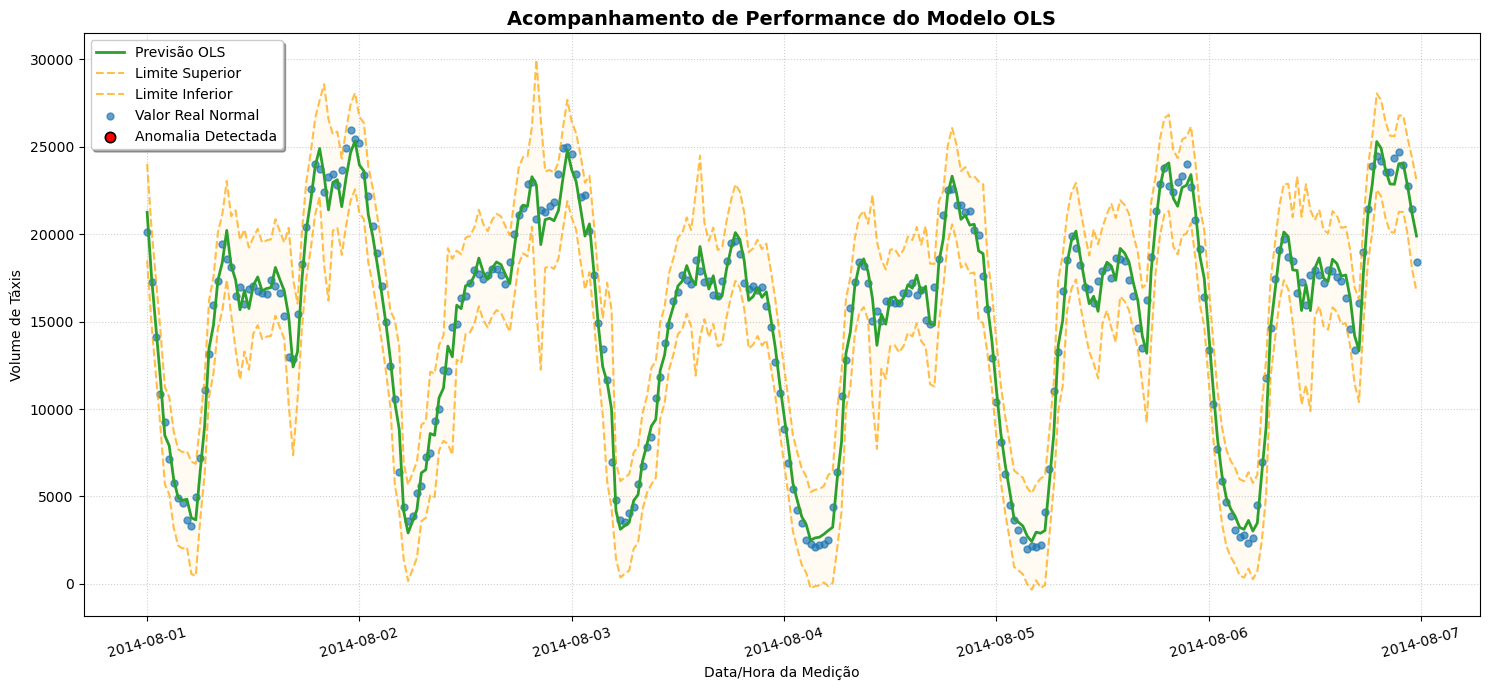

In [79]:
# Grafico demonstrandos os valores previso vs o real, anomalias e as bandas
df_plot = df_calibracao_model1.copy()

df_plot['anomalia'] = (
    (df_plot['y'] > df_plot['yhat_upper'])
)

df_normal = df_plot[df_plot['anomalia'] == False]
df_anomalias = df_plot[df_plot['anomalia'] == True]

plt.figure(figsize=(15, 7))

plt.plot(
    df_plot['ds'],
    df_plot['yhat'],
    color='#2ca02c',
    linewidth=2,
    label='Previsão OLS'
)

plt.plot(
    df_plot['ds'],
    df_plot['yhat_upper'],
    color='orange',
    linestyle='--',
    alpha=0.7,
    label='Limite Superior'
)

plt.plot(
    df_plot['ds'],
    df_plot['yhat_lower'],
    color='orange',
    linestyle='--',
    alpha=0.7,
    label='Limite Inferior'
)

plt.fill_between(
    df_plot['ds'],
    df_plot['yhat_lower'],
    df_plot['yhat_upper'],
    color='orange',
    alpha=0.05
)

plt.scatter(
    df_normal['ds'],
    df_normal['y'],
    color='#1f77b4',
    s=25,
    alpha=0.7,
    label='Valor Real Normal'
)

plt.scatter(
    df_anomalias['ds'],
    df_anomalias['y'],
    color='red',
    s=55,
    marker='o',
    edgecolors='black',
    linewidths=1.2,
    zorder=5,
    label='Anomalia Detectada'
)

plt.title('Acompanhamento de Performance do Modelo OLS', fontsize=14, fontweight='bold')
plt.xlabel('Data/Hora da Medição')
plt.ylabel('Volume de Táxis')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left', frameon=True, shadow=True)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 03 - Métricas de drift

Nesta seção, são definidas as métricas usadas para monitorar a degradação do modelo ao longo do tempo.  
O objetivo é comparar o comportamento atual do modelo com a janela histórica de calibração.  
São avaliados sinais como aumento do MAE, mudança na distribuição dos erros, crescimento da taxa de anomalias e maior volatilidade dos resíduos.  
Essas métricas funcionam como gatilhos para indicar que o modelo pode não estar mais representando bem o padrão dos dados.  
Quando múltiplos sinais de drift aparecem ao mesmo tempo, o modelo passa a ser candidato ao retreinamento.

### 03.1 - `drift_distribuicao_erros`

A função `drift_distribuicao_erros` avalia se a distribuição dos erros recentes do modelo mudou em relação aos erros históricos da janela de calibração.

Para isso, ela utiliza o teste estatístico Kolmogorov-Smirnov, que compara duas distribuições: os erros históricos e os erros observados em uma janela recente.

Se o `p-value` for menor que o nível de significância definido, normalmente `0.05`, entende-se que há evidência estatística de mudança no padrão dos erros.

Nesse caso, a função sinaliza `drift = True`, indicando que o modelo pode estar errando de uma forma diferente da esperada.

Essa métrica é importante porque o drift pode ocorrer mesmo quando o erro médio ainda não aumentou muito, mas a forma da distribuição dos resíduos já mudou.

In [80]:
def drift_distribuicao_erros(erros_historicos, erros_janela, alpha=0.05):
    stat, p_value = ks_2samp(erros_historicos, erros_janela)
    drift = p_value < alpha

    return {
        'ks_stat': stat,
        'p_value': p_value,
        'drift': drift
    }

### 03.2 - `drift_mae`

A função `drift_mae` avalia se o erro médio absoluto do modelo aumentou de forma relevante em uma janela recente.

Para isso, ela calcula o MAE da janela atual, usando os erros absolutos mais recentes do modelo.

Esse valor é comparado com um limite histórico definido na etapa de calibração, chamado `threshold_mae`.

Se o MAE recente for maior que esse limite, a função sinaliza `drift = True`.

Essa métrica é importante porque indica perda direta de desempenho: o modelo continua fazendo previsões, mas seus erros passaram a ficar maiores do que o esperado para um comportamento normal.

In [81]:
def drift_mae(erros_janela_abs, threshold_mae):
    mae_janela = np.mean(erros_janela_abs)
    drift = mae_janela > threshold_mae

    return {
        'mae_janela': mae_janela,
        'threshold_mae': threshold_mae,
        'drift': drift
    }

### 03.3 - `drift_taxa_anomalia`

A função `drift_taxa_anomalia` avalia se a quantidade de pontos classificados como anomalia aumentou em uma janela recente.

Para isso, ela compara os valores reais `y_real` com os limites inferior e superior da banda de previsão.

Quando o valor real fica fora da banda, ele é marcado como anomalia.

Em seguida, a função calcula a proporção de anomalias na janela atual e compara com o limite `threshold_taxa_anomalia`.

Se a taxa recente ultrapassar esse limite, a função sinaliza `drift = True`, indicando que o modelo está encontrando mais comportamentos fora do esperado do que na calibração.

In [82]:
def drift_taxa_anomalia(y_real, yhat_lower, yhat_upper, threshold_taxa_anomalia):
    anomalias = (y_real > yhat_upper) | (y_real < yhat_lower)
    taxa = np.mean(anomalias)
    drift = taxa > threshold_taxa_anomalia

    return {
        'taxa_anomalia': taxa,
        'threshold_taxa_anomalia': threshold_taxa_anomalia,
        'drift': drift
    }

### 03.4 - `drift_volatilidade_residuos`

A função `drift_volatilidade_residuos` avalia se os erros recentes do modelo ficaram mais instáveis em relação ao comportamento histórico.

Para isso, ela calcula o desvio padrão dos erros em uma janela recente.

Esse valor é comparado com o limite `threshold_residual_std`, definido a partir da volatilidade dos resíduos na janela de calibração.

Se o desvio padrão recente for maior que esse limite, a função sinaliza `drift = True`.

Essa métrica é importante porque o modelo pode começar a oscilar mais, mesmo antes de apresentar um aumento claro no erro médio.

In [83]:
historical_residual_std = df_calibracao_model1['erro'].std()
threshold_residual_std = historical_residual_std * 1.5

def drift_volatilidade_residuos(erros_janela, threshold_residual_std):
    std_janela = np.std(erros_janela)
    drift = std_janela > threshold_residual_std

    return {
        'std_janela': std_janela,
        'threshold_residual_std': threshold_residual_std,
        'drift': drift
    }

In [85]:
# 1. Recupera os erros históricos da janela de calibração
# Esses valores serão usados como referência para definir os thresholds de drift
historical_errors = df_calibracao_model1['erro'].values
historical_abs_errors = df_calibracao_model1['abs_erro'].values

# 2. Calcula as métricas históricas que representam o comportamento normal do modelo
historical_mae_mean = df_calibracao_model1['abs_erro'].mean()
historical_mae_std = df_calibracao_model1['abs_erro'].std()
historical_error_std = df_calibracao_model1['erro'].std()

# 3. Define os thresholds de alerta para MAE e volatilidade dos resíduos
# O threshold de MAE usa média + 3 desvios-padrão dos erros absolutos
# O threshold de volatilidade permite até 50% acima do desvio padrão histórico
threshold_mae = historical_mae_mean + 3 * historical_mae_std
threshold_residual_std = historical_error_std * 1.5

# 4. Define o fator usado na construção das bandas de previsão
# z = 2.576 representa aproximadamente uma banda de 99%, assumindo resíduos próximos da normalidade
z = 2.576

# 5. Calcula a taxa histórica de anomalias na janela de calibração
df_calibracao_model1['anomalia'] = (
    (df_calibracao_model1['y'] > df_calibracao_model1['yhat_upper']) |
    (df_calibracao_model1['y'] < df_calibracao_model1['yhat_lower'])
)

taxa_anomalia_esperada = df_calibracao_model1['anomalia'].mean()

# 6. Define o threshold da taxa de anomalias
# Usa uma folga sobre a taxa histórica, garantindo no mínimo 2% como limite de alerta
threshold_taxa_anomalia = max(taxa_anomalia_esperada + 0.01, 0.02)

print(f"Baseline MAE histórico: {historical_mae_mean:.4f}")
print(f"Threshold MAE: {threshold_mae:.4f}")
print(f"STD histórico dos resíduos: {historical_error_std:.4f}")
print(f"Threshold volatilidade resíduos: {threshold_residual_std:.4f}")
print(f"Taxa esperada de anomalias: {taxa_anomalia_esperada:.4f}")
print(f"Threshold taxa de anomalias: {threshold_taxa_anomalia:.4f}")

Baseline MAE histórico: 771.2207
Threshold MAE: 2546.1006
STD histórico dos resíduos: 972.3484
Threshold volatilidade resíduos: 1458.5226
Taxa esperada de anomalias: 0.0000
Threshold taxa de anomalias: 0.0200


In [86]:
# Definição da largura das bandas no dataset de calibração
df_calibracao_model1['largura_banda'] = df_calibracao_model1['yhat_upper'] - df_calibracao_model1['yhat_lower']

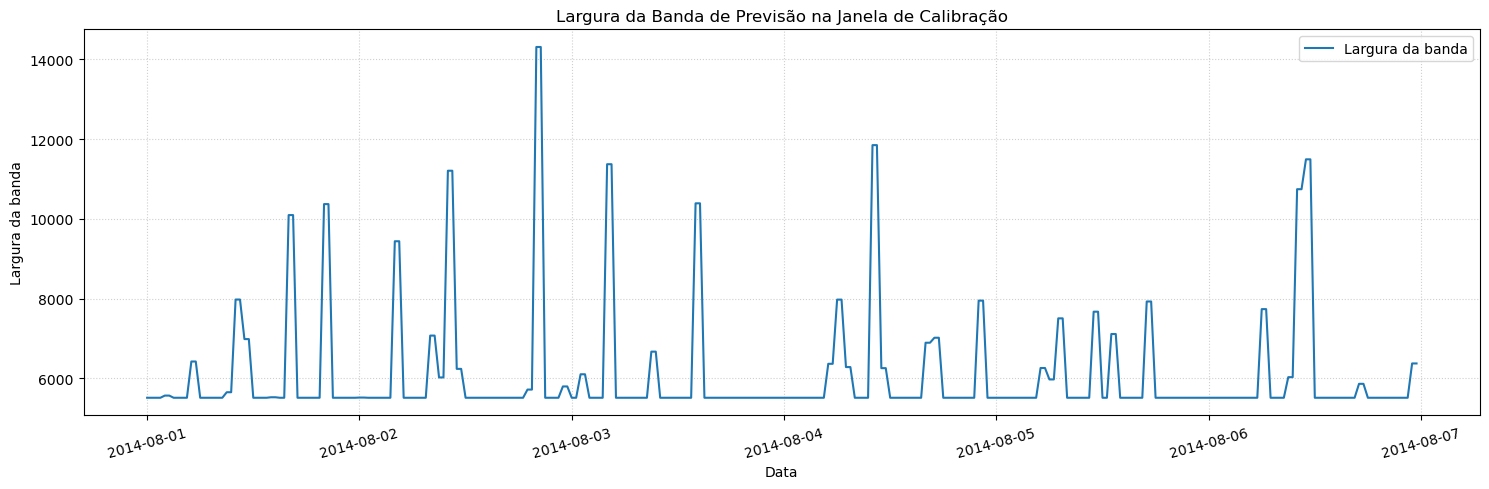

In [87]:
# plot da largura das badas
plt.figure(figsize=(15, 5))

plt.plot(
    df_calibracao_model1['ds'],
    df_calibracao_model1['largura_banda'],
    label='Largura da banda'
)

plt.title('Largura da Banda de Previsão na Janela de Calibração')
plt.xlabel('Data')
plt.ylabel('Largura da banda')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

#### Suavização da largura da banda por B-Spline

Nesta etapa, é aplicada uma suavização sobre a série da largura da banda de previsão calculada na janela de calibração.

Primeiro, é criado um eixo numérico `x` para representar a ordem temporal dos registros, enquanto `y_band` armazena os valores originais da largura da banda.

Em seguida, é ajustada uma B-Spline por meio da função `UnivariateSpline`, com o objetivo de reduzir oscilações pontuais e destacar a tendência geral da largura da banda ao longo do tempo.

A série suavizada é armazenada na coluna `largura_banda_suavizada`.

Por fim, o gráfico compara a largura original da banda com a versão suavizada, permitindo visualizar se a incerteza do modelo apresenta um comportamento estável ou alguma tendência de aumento na janela de calibração.

In [58]:
# Suaviza a largura da banda de previsão usando B-Spline para capturar a tendência geral da incerteza do modelo na calibração
x = np.arange(len(df_calibracao_model1))
y_band = df_calibracao_model1['largura_banda'].values

spline = UnivariateSpline(x, y_band, s=len(x) * np.var(y_band) * 0.05)

df_calibracao_model1['largura_banda_suavizada'] = spline(x)

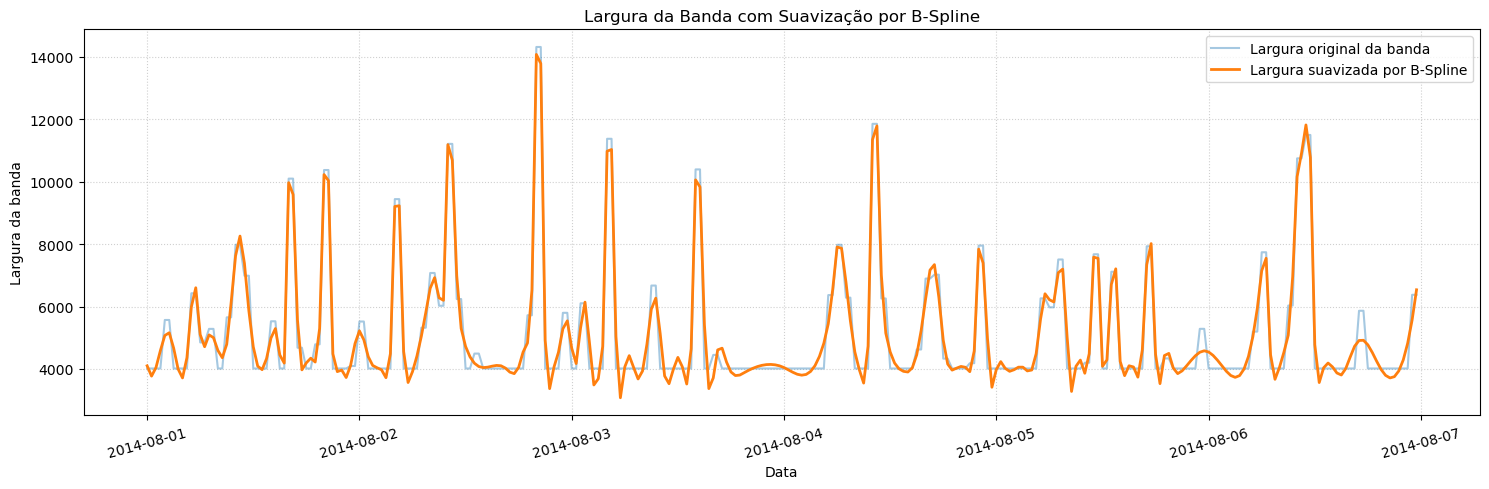

In [59]:
# plot da largura da banda vs a suavizada por B-Splines
plt.figure(figsize=(15, 5))

plt.plot(
    df_calibracao_model1['ds'],
    df_calibracao_model1['largura_banda'],
    alpha=0.4,
    label='Largura original da banda'
)

plt.plot(
    df_calibracao_model1['ds'],
    df_calibracao_model1['largura_banda_suavizada'],
    linewidth=2,
    label='Largura suavizada por B-Spline'
)

plt.title('Largura da Banda com Suavização por B-Spline')
plt.xlabel('Data')
plt.ylabel('Largura da banda')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

A B-Spline foi utilizada para suavizar a série da largura da banda de previsão, permitindo observar a tendência geral da incerteza do modelo ao longo da janela de calibração.

### Proporção entre Erro Absoluto e Largura da Banda (Lógica do cálculo)
Nesta etapa, é calculada a razão entre o erro absoluto do modelo e a largura da banda de previsão.

Essa métrica mostra quanto da tolerância da banda está sendo consumida pelo erro do modelo em cada ponto da janela de calibração.

Quando o valor está abaixo de `1`, o erro ainda está dentro da largura da banda. Valores próximos ou acima de `1` indicam que o erro está ocupando toda a banda de tolerância, sugerindo maior risco de anomalia ou piora de desempenho.

O gráfico permite acompanhar essa proporção ao longo do tempo e verificar se os erros permanecem controlados em relação à incerteza esperada do modelo.

Em outras palavras esse gráfico mede o tamanho do erro do modelo em relação à largura da banda de previsão.

$${Proporção} = \frac{|y - \hat{y}|}{yhat\_upper - yhat\_lower}$$

Valores baixos indicam que o erro está pequeno em relação à tolerância da banda.

Valores próximos ou acima de 1 indicam que o erro está consumindo grande parte da banda, sugerindo maior risco de anomalia.

No trabalho, essa métrica ajuda a avaliar se a banda está larga o suficiente para absorver os erros esperados do modelo.

In [60]:
# Calcula quanto do intervalo de tolerância da banda está sendo consumido pelo erro absoluto do modelo
df_calibracao_model1['erro_sobre_banda'] = (
    df_calibracao_model1['abs_erro'] / df_calibracao_model1['largura_banda']
)

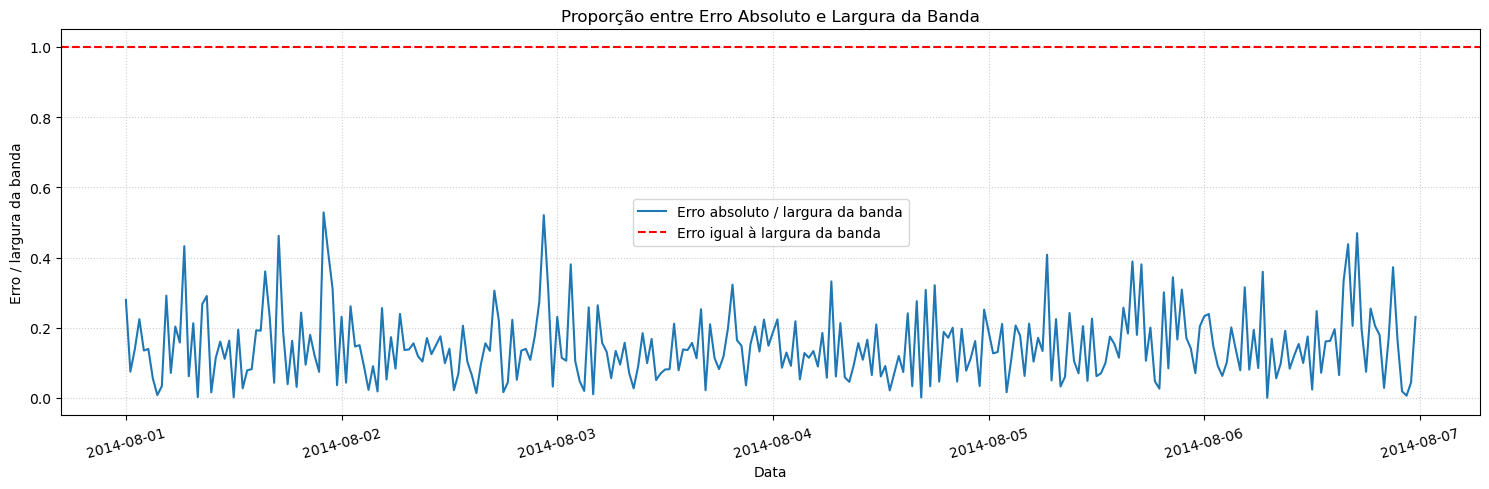

In [61]:
# plto do intervalo de tolerância da banda sendo consumido vs o threshold
plt.figure(figsize=(15, 5))

plt.plot(
    df_calibracao_model1['ds'],
    df_calibracao_model1['erro_sobre_banda'],
    label='Erro absoluto / largura da banda'
)

plt.axhline(
    1,
    linestyle='--',
    color='red',
    label='Erro igual à largura da banda'
)

plt.title('Proporção entre Erro Absoluto e Largura da Banda')
plt.xlabel('Data')
plt.ylabel('Erro / largura da banda')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [62]:
# Define as referências históricas da largura da banda suavizada, usadas como limite de controle para monitorar aumento da incerteza do modelo
limite_largura_banda = df_calibracao_model1['largura_banda_suavizada'].mean()
limite_largura_banda_std = df_calibracao_model1['largura_banda_suavizada'].std()

print(f'Media das larguras das bandas: {limite_largura_banda}')
print(f'STD das larguras das bandas: {limite_largura_banda_std}')

Media das larguras das bandas: 5134.630777758118
STD das larguras das bandas: 1909.855436969519


## 03 - Previsão de novos casos até o drift do modelo
Agora iremos jogar evento a evento no modelo e iremos medir a performance e verificar se o modelo apresenta sinais de drift, quando isso acontecer iremos parar o loop e observar como estão as métricas

In [92]:
stream_timestamps = []
stream_errors = []
stream_maes = []
anomaly_flags = []
real_value = []
valor_previsto = []
limite_inferior = []
limite_superior = []
stream_bandwidths = []
largura_banda_atual_list = []
media_largura_banda_recente_list = []


monitoramento = []

window_size = 48 # as medições são feitas a cada 30 minutos usar 48 siginifica trabalhar com as últimas 24 horas
ks_window_size = 96 # Para medição do p-value entre distribuição vamos usar 96 que equivale à 2 dias
min_drift_signals = 3 # a simulação para se tivermos 3 ou mais sinais de drift

print("Iniciando simulação de streaming com modelo OLS...")

drift_detectado = False
drift_timestamp = None
drift_index = None

for pos, (_, row) in enumerate(df_stream.iterrows()):

    flag_anomalia = 0
    flag_distribuicao_erro = 0
    flag_volatilidade = 0
    flag_mae = 0
    flag_banda = 0

    # 1. Predição do ponto atual com OLS
    current_df = pd.DataFrame([row])

    X_current = current_df[features]

    y_real = row['y']
    y_hat = ols.predict(X_current)[0]

    # 2. Banda de previsão baseada nos resíduos históricos
    banda_ajustada = calcular_banda_ajustada(row)

    y_lower = y_hat - banda_ajustada
    y_upper = y_hat + banda_ajustada
    largura_banda_atual = y_upper - y_lower

    # 3. Cálculo do erro
    error = y_real - y_hat
    abs_error = abs(error)

    stream_timestamps.append(row['ds'])
    stream_errors.append(float(error))
    real_value.append(y_real)
    valor_previsto.append(y_hat)
    limite_inferior.append(y_lower)
    limite_superior.append(y_upper)
    stream_bandwidths.append(largura_banda_atual)
    largura_banda_atual_list.append(largura_banda_atual)


    # 4. Anomalia pontual
    is_anomaly = 1 if (y_real > y_upper) else 0
    anomaly_flags.append(is_anomaly)

    # 5. MAE em janela móvel
    recent_errors = stream_errors[-window_size:]
    recent_abs_errors = np.abs(recent_errors)
    current_mae = np.mean(recent_abs_errors)
    stream_maes.append(current_mae)

    if len(recent_errors) >= window_size:
        if current_mae > threshold_mae:
            flag_mae = 1

    # 6. Taxa de anomalias em janela móvel
    recent_anomalies = anomaly_flags[-window_size:]
    taxa_anomalia_movel = np.mean(recent_anomalies)

    if len(recent_anomalies) >= window_size:
        if taxa_anomalia_movel > threshold_taxa_anomalia:
            flag_anomalia = 1

    # 7. Volatilidade dos resíduos em janela móvel
    std_residuos_movel = np.std(recent_errors)

    if len(recent_errors) >= window_size:
        if std_residuos_movel > threshold_residual_std:
            flag_volatilidade = 1

    # 8. KS-Test para comparar distribuição de erros
    ks_p_value = np.nan
    ks_stat = np.nan

    if len(stream_errors) >= ks_window_size and pos % 20 == 0:
        erros_recentes_ks = stream_errors[-ks_window_size:]

        ks_stat, ks_p_value = ks_2samp(
            historical_errors,
            erros_recentes_ks
        )

        if ks_p_value <= 0.05:
            flag_distribuicao_erro = 1

    # 9. Largura das bandas
    recent_bandwidths = stream_bandwidths[-window_size:]
    media_largura_banda_recente = np.nan

    if len(recent_bandwidths) >= window_size:
        x_recent = np.arange(len(recent_bandwidths))
        y_recent = np.array(recent_bandwidths)

        s_base = len(y_recent) * np.var(y_recent) * 5

        s_floor = len(y_recent) * (0.05 * np.mean(np.abs(y_recent))) ** 2
        
        s_spline = max(s_base, s_floor, 1.0)
        
        spline_largura_banda_recente = UnivariateSpline(
            x_recent,
            y_recent,
            s=s_spline,
            k=3
        )

        largura_banda_suavizada_recente = spline_largura_banda_recente(x_recent)

        media_largura_banda_recente = np.mean(largura_banda_suavizada_recente)

        media_largura_banda_recente_list.append(media_largura_banda_recente)
        if media_largura_banda_recente > (limite_largura_banda+limite_largura_banda_std*3):
            flag_banda = 1

    # 10. Somatória dos sinais de drift
    qtd_sinais_drift = (
        flag_mae +
        flag_anomalia +
        flag_volatilidade +
        flag_distribuicao_erro +
        flag_banda
    )

    drift_na_linha = qtd_sinais_drift >= min_drift_signals

    # 11. Guardar resultado do monitoramento
    monitoramento.append({
        'posicao_stream': pos,
        'ds': row['ds'],
        'y': y_real,
        'yhat': y_hat,
        'yhat_lower': y_lower,
        'yhat_upper': y_upper,
        'erro': error,
        'abs_erro': abs_error,
        'mae_movel': current_mae,
        'std_residuos_movel': std_residuos_movel,
        'taxa_anomalia_movel': taxa_anomalia_movel,
        'ks_stat': ks_stat,
        'ks_p_value': ks_p_value,
        'largura_banda': largura_banda_atual,
        'media_largura_banda_suavizada': media_largura_banda_recente,
        'flag_mae': flag_mae,
        'flag_anomalia': flag_anomalia,
        'flag_volatilidade': flag_volatilidade,
        'flag_distribuicao_erro': flag_distribuicao_erro,
        'flag_banda': flag_banda,
        'qtd_sinais_drift': qtd_sinais_drift,
        'drift_detectado': drift_na_linha
    })

    # 12. Condição de parada
    if drift_na_linha:
        drift_detectado = True
        drift_timestamp = row['ds']
        drift_index = pos

        print("Drift detectado! Parando simulação.")
        print(f"Data/hora do drift: {drift_timestamp}")
        print(f"Medições até o drift: {pos + 1}")
        print(f"Quantidade de sinais ativos: {qtd_sinais_drift}")

        if flag_mae:
            print("- MAE degradado")
        if flag_anomalia:
            print("- Taxa de anomalias acima do esperado")
        if flag_volatilidade:
            print("- Volatilidade dos resíduos elevada")
        if flag_distribuicao_erro:
            print("- Distribuição dos erros diferente da calibração")
        if flag_banda:
            print("- Aumento das bandas de previsão")

        break

df_monitoramento = pd.DataFrame(monitoramento)

Iniciando simulação de streaming com modelo OLS...
Drift detectado! Parando simulação.
Data/hora do drift: 2014-09-14 08:00:00
Medições até o drift: 1841
Quantidade de sinais ativos: 3
- Taxa de anomalias acima do esperado
- Volatilidade dos resíduos elevada
- Distribuição dos erros diferente da calibração


In [93]:
df_monitoramento_completo = df_monitoramento.copy()
df_monitoramento = df_monitoramento[-300:]

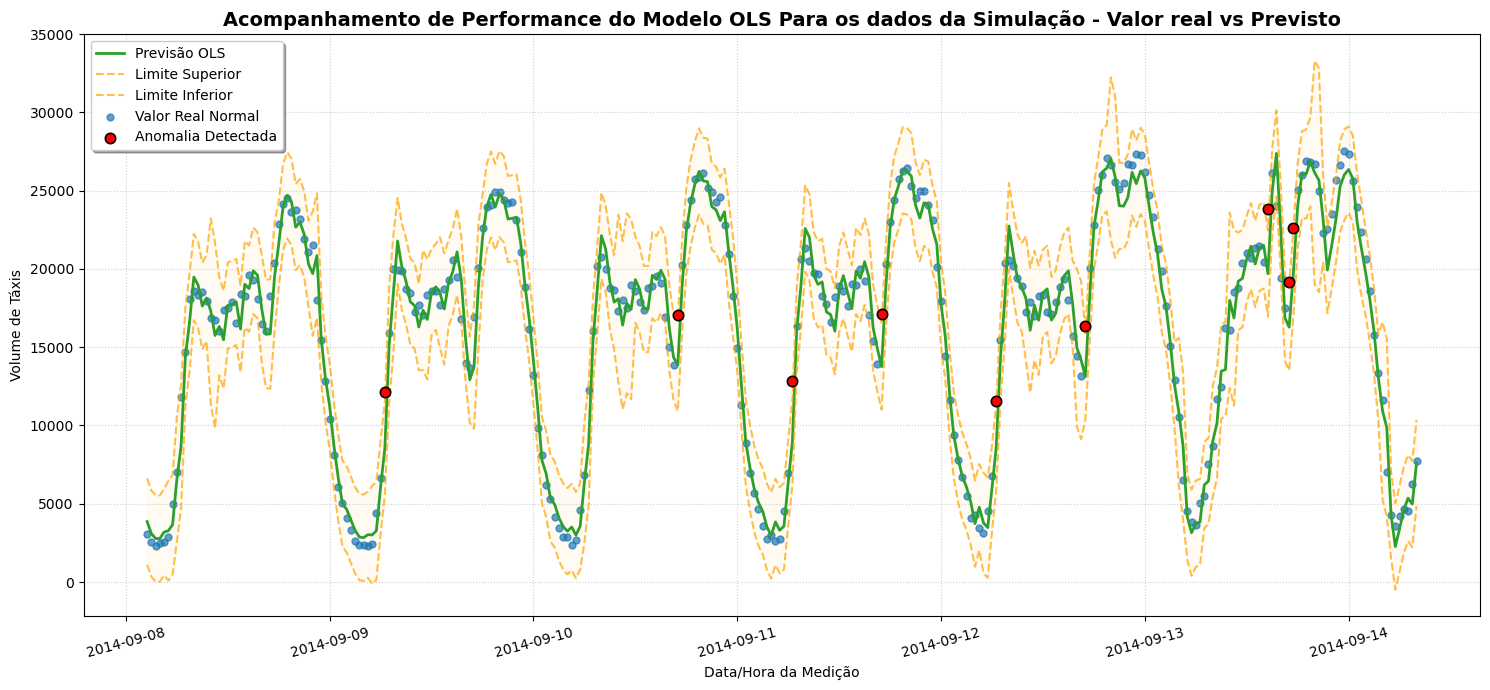

In [94]:
df_plot = df_monitoramento.copy()

df_plot['anomalia'] = (
    (df_plot['y'] > df_plot['yhat_upper'])
)

df_normal = df_plot[df_plot['anomalia'] == False]
df_anomalias = df_plot[df_plot['anomalia'] == True]

plt.figure(figsize=(15, 7))

plt.plot(
    df_plot['ds'],
    df_plot['yhat'],
    color='#2ca02c',
    linewidth=2,
    label='Previsão OLS'
)

plt.plot(
    df_plot['ds'],
    df_plot['yhat_upper'],
    color='orange',
    linestyle='--',
    alpha=0.7,
    label='Limite Superior'
)

plt.plot(
    df_plot['ds'],
    df_plot['yhat_lower'],
    color='orange',
    linestyle='--',
    alpha=0.7,
    label='Limite Inferior'
)

plt.fill_between(
    df_plot['ds'],
    df_plot['yhat_lower'],
    df_plot['yhat_upper'],
    color='orange',
    alpha=0.05
)

plt.scatter(
    df_normal['ds'],
    df_normal['y'],
    color='#1f77b4',
    s=25,
    alpha=0.7,
    label='Valor Real Normal'
)

plt.scatter(
    df_anomalias['ds'],
    df_anomalias['y'],
    color='red',
    s=55,
    marker='o',
    edgecolors='black',
    linewidths=1.2,
    zorder=5,
    label='Anomalia Detectada'
)

plt.title('Acompanhamento de Performance do Modelo OLS Para os dados da Simulação - Valor real vs Previsto', fontsize=14, fontweight='bold')
plt.xlabel('Data/Hora da Medição')
plt.ylabel('Volume de Táxis')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left', frameon=True, shadow=True)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

Esse gráfico “Acompanhamento de Performance do Modelo OLS Para os dados da Simulação - Valor real vs Previsto” é o gráfico principal para mostrar visualmente a degradação do modelo ao longo do stream.<br/>

Ele compara, ao longo do tempo:<br/>

 - o valor real observado da série (ponto azul e vermelho)
 - o valor previsto pelo modelo OLS (linha verde)
 - a banda de tolerância/previsão (bandas em amarelo)
 - os pontos considerados anômalos (pontos em vermelho)

A ideia central é mostrar se o modelo que foi treinado no passado continua acompanhando bem os dados novos ou se começa a se afastar do comportamento real.

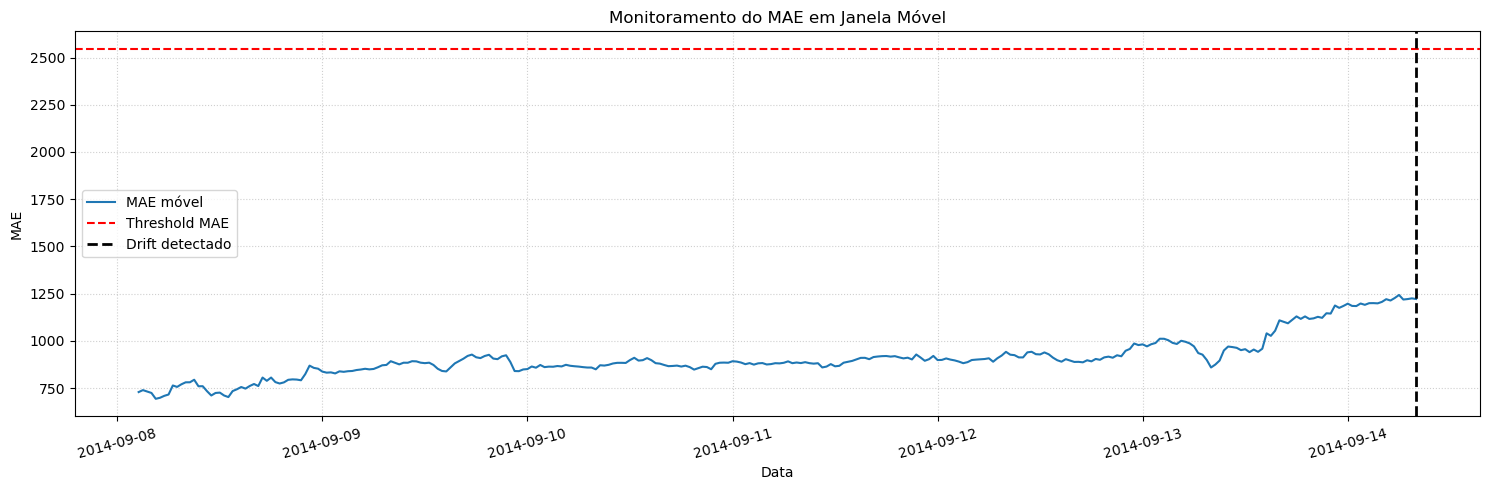

In [95]:
# MAE móvel
plt.figure(figsize=(15, 5))

plt.plot(
    df_monitoramento['ds'],
    df_monitoramento['mae_movel'],
    label='MAE móvel'
)

plt.axhline(
    threshold_mae,
    color='red',
    linestyle='--',
    label='Threshold MAE'
)

if drift_detectado:
    plt.axvline(
        drift_timestamp,
        color='black',
        linestyle='--',
        linewidth=2,
        label='Drift detectado'
    )

plt.title('Monitoramento do MAE em Janela Móvel')
plt.xlabel('Data')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

#### MAE móvel


O MAE móvel mede o erro absoluto médio do modelo em uma janela recente do stream, estamos considerando até às últimas 20 medições.

$$MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

Quando o MAE móvel aumenta, significa que o modelo está errando mais nas observações recentes.

Se ele ultrapassa o limite definido na calibração, isso indica degradação de performance.

No trabalho, essa métrica é usada como um dos sinais de possível drift.

Apensar de não ter disparado um sinal de drift é nítido que o erro vem aumentando gradualmente.

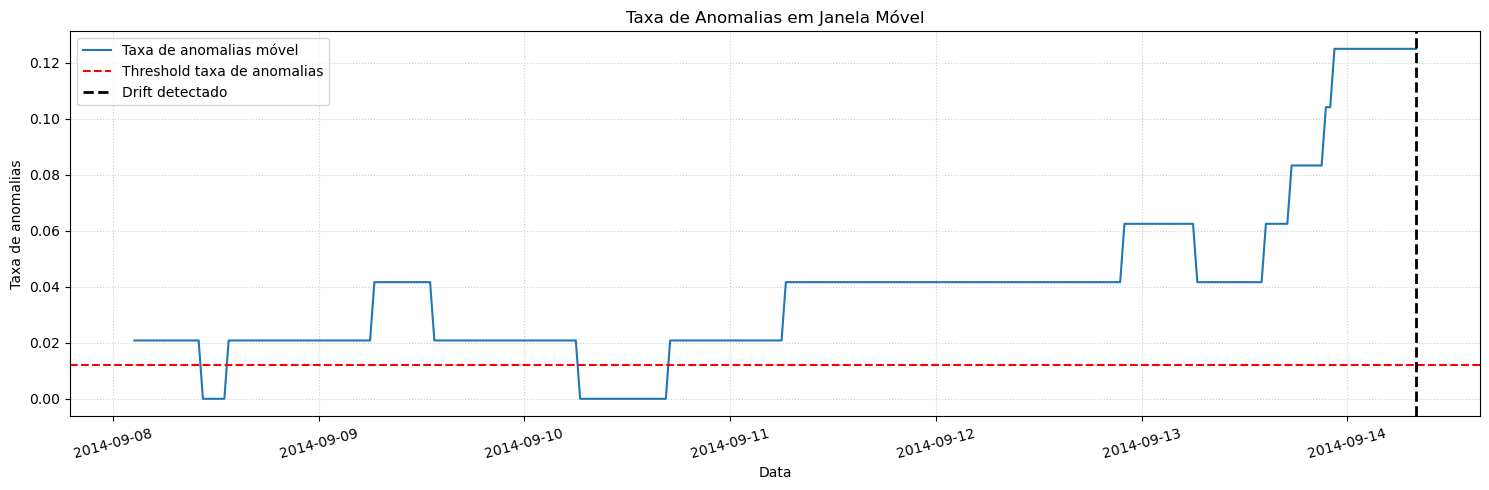

In [67]:
# Taxa móvel de anomalias
plt.figure(figsize=(15, 5))

plt.plot(
    df_monitoramento['ds'],
    df_monitoramento['taxa_anomalia_movel'],
    label='Taxa de anomalias móvel'
)

plt.axhline(
    threshold_taxa_anomalia,
    color='red',
    linestyle='--',
    label='Threshold taxa de anomalias'
)

if drift_detectado:
    plt.axvline(
        drift_timestamp,
        color='black',
        linestyle='--',
        linewidth=2,
        label='Drift detectado'
    )

plt.title('Taxa de Anomalias em Janela Móvel')
plt.xlabel('Data')
plt.ylabel('Taxa de anomalias')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

#### Taxa móvel de anomalias

A taxa móvel de anomalias mede a proporção de pontos fora da banda de previsão em uma janela recente do stream.

$$Taxa = \frac{\text{número de anomalias na janela}}{\text{número total de observações na janela}}$$

Quando essa taxa aumenta, significa que mais observações recentes estão se afastando do comportamento esperado.

Se ela ultrapassa o limite definido na calibração (linha em vermelho), isso indica possível degradação do modelo.

O threshold para essa métrica era de 2% e chegamos ao patamar de 12% evidênciando um drift do modelo que pode estar relacionado a mudança no comportamento dos dados.

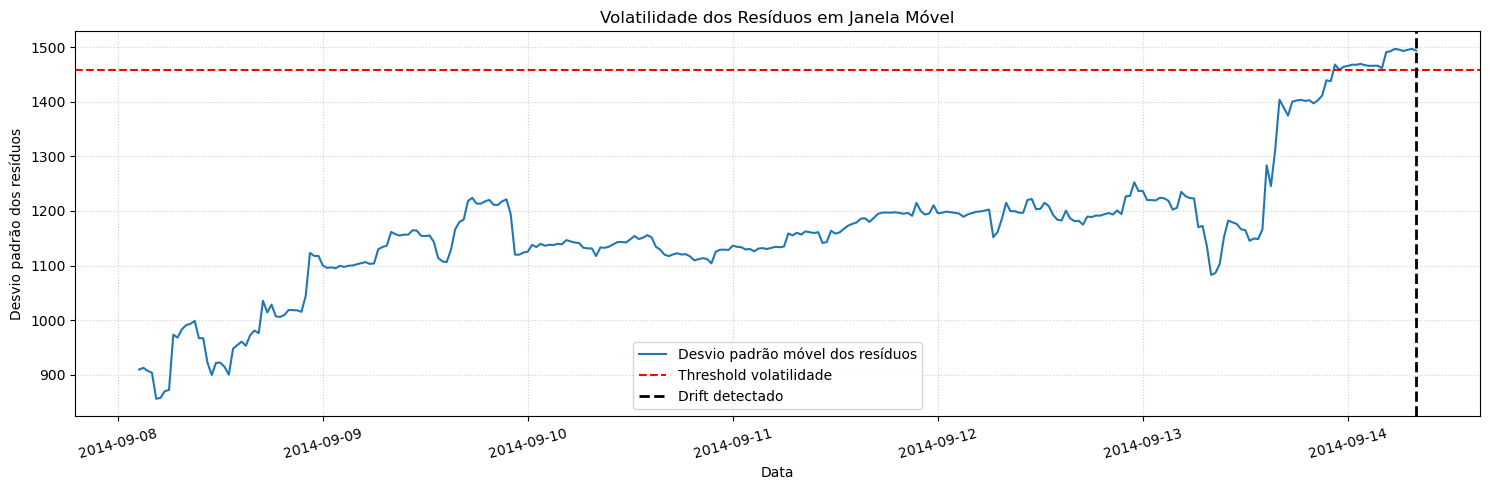

In [68]:
# Volatilidade dos resíduos
plt.figure(figsize=(15, 5))

plt.plot(
    df_monitoramento['ds'],
    df_monitoramento['std_residuos_movel'],
    label='Desvio padrão móvel dos resíduos'
)

plt.axhline(
    threshold_residual_std,
    color='red',
    linestyle='--',
    label='Threshold volatilidade'
)

if drift_detectado:
    plt.axvline(
        drift_timestamp,
        color='black',
        linestyle='--',
        linewidth=2,
        label='Drift detectado'
    )

plt.title('Volatilidade dos Resíduos em Janela Móvel')
plt.xlabel('Data')
plt.ylabel('Desvio padrão dos resíduos')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

#### Volatilidade dos resíduos

A volatilidade dos resíduos mede a variação dos erros do modelo em uma janela recente do stream usando as últimas 20 medições.

$$sigma_{\text{resíduos}} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(e_i - \bar{e})^2}$$

Quando essa volatilidade aumenta, significa que os erros recentes ficaram mais instáveis.

Se ela ultrapassa o limite definido na calibração (linha em vermelho), isso indica aumento da incerteza do modelo sinal de possível drift.

Fica evidente que o delta entre o valor previsto e o realizado vem aumentando, fazendo com que as previsões se tornem mais instaveis e é outro sinal claro de drift.

In [96]:
# medição do tamanho da banda
df_monitoramento['largura_banda'] = (
    df_monitoramento['yhat_upper'] - df_monitoramento['yhat_lower']
)

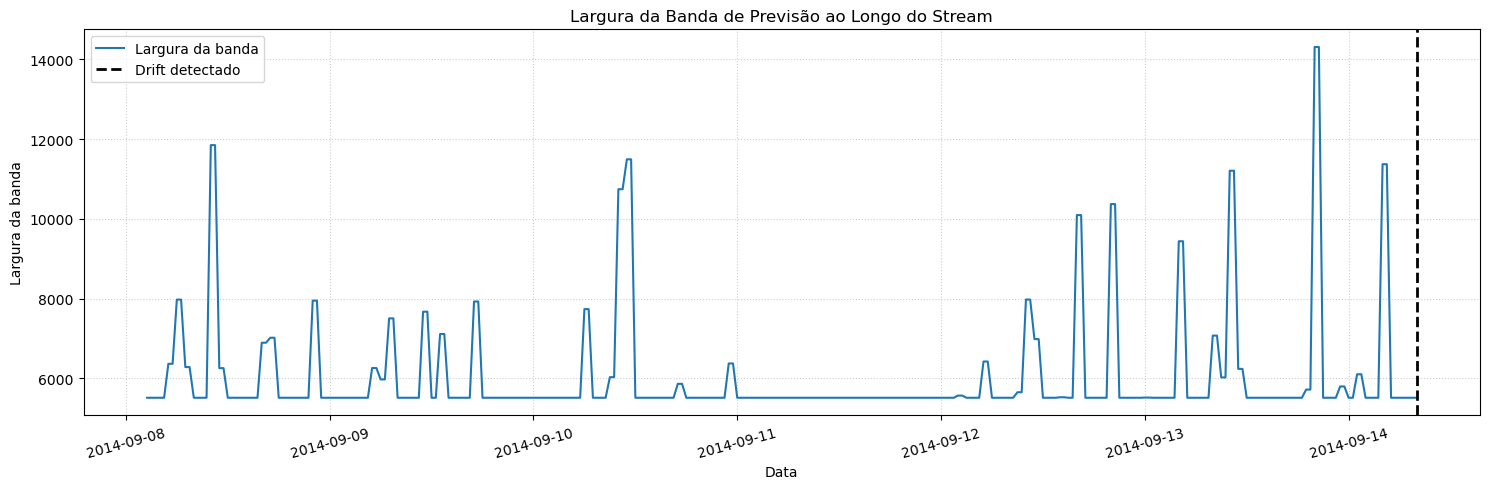

In [98]:
# plot da largura da banda
plt.figure(figsize=(15, 5))

plt.plot(
    df_monitoramento['ds'],
    df_monitoramento['largura_banda'],
    label='Largura da banda'
)

if drift_detectado:
    plt.axvline(
        drift_timestamp,
        color='black',
        linestyle='--',
        linewidth=2,
        label='Drift detectado'
    )

plt.title('Largura da Banda de Previsão ao Longo do Stream')
plt.xlabel('Data')
plt.ylabel('Largura da banda')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

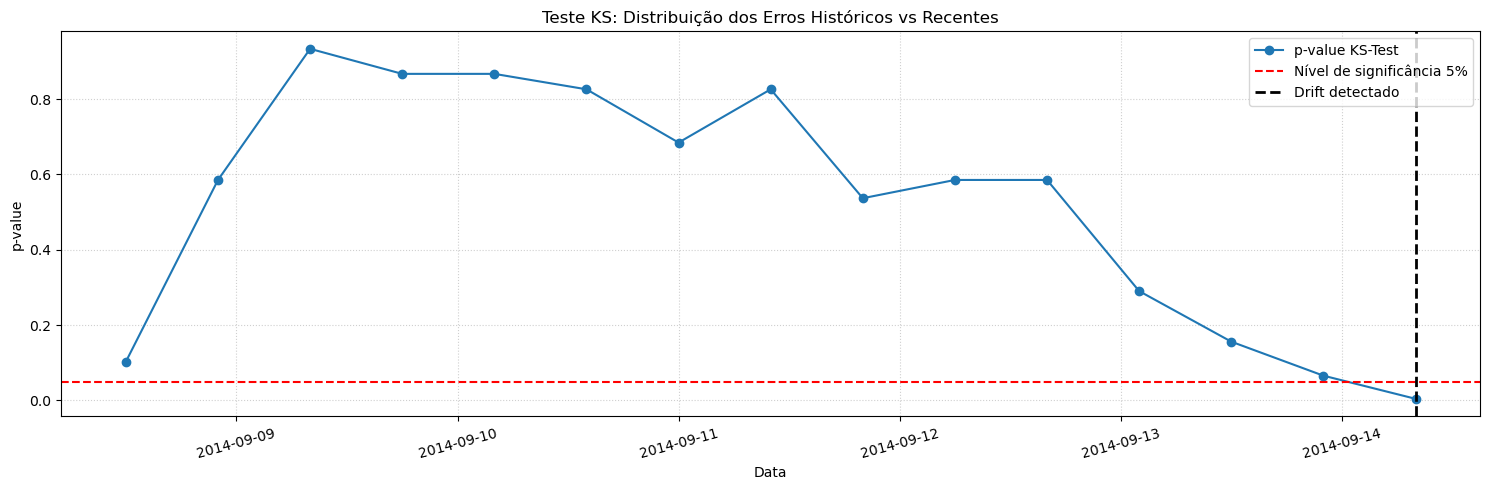

In [99]:
# P-value do KS-Test
df_ks = df_monitoramento.dropna(subset=['ks_p_value'])

plt.figure(figsize=(15, 5))

plt.plot(
    df_ks['ds'],
    df_ks['ks_p_value'],
    marker='o',
    label='p-value KS-Test'
)

plt.axhline(
    0.05,
    color='red',
    linestyle='--',
    label='Nível de significância 5%'
)

if drift_detectado:
    plt.axvline(
        drift_timestamp,
        color='black',
        linestyle='--',
        linewidth=2,
        label='Drift detectado'
    )

plt.title('Teste KS: Distribuição dos Erros Históricos vs Recentes')
plt.xlabel('Data')
plt.ylabel('p-value')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

#### P-value do KS-Test

O KS-Test compara a distribuição dos erros históricos com a distribuição dos erros recentes do stream.

$$H_0: F_{\text{histórico}}(e) = F_{\text{recente}}(e)$$

O p-value indica se há evidência estatística de mudança entre essas distribuições.

Quando $$(p\text{-value} < 0{,}05), rejeitamos (H_0)$$ e sinalizamos possível mudança no padrão dos erros o que é um sinal de drift.

Como o p-value me se duas distribuições são estatísticamente iguais esse valor cair para baixo de 0.05 indica que a distribuições não são mais iguais, então temos mais uma prova do drift porque a distribuição do periódo de calibração e o atual são diferentes.

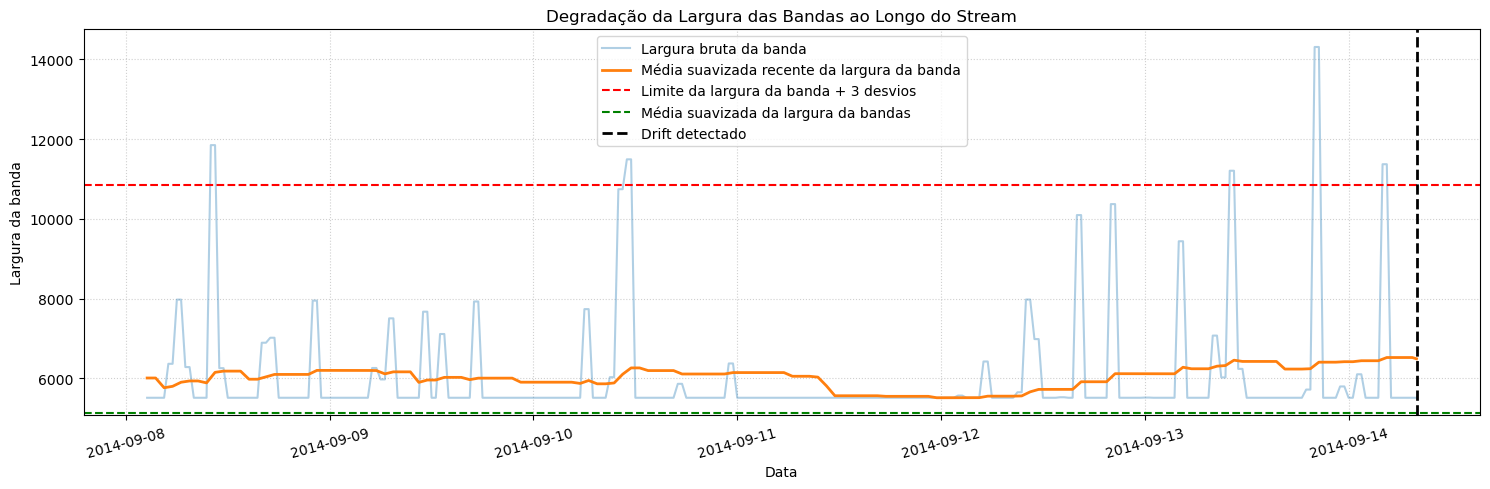

In [100]:
# plot da largura das bandas com a média movel dos periodos recentes
plt.figure(figsize=(15, 5))

plt.plot(
    df_monitoramento['ds'],
    df_monitoramento['largura_banda'],
    alpha=0.35,
    label='Largura bruta da banda'
)

plt.plot(
    df_monitoramento['ds'],
    df_monitoramento['media_largura_banda_suavizada'],
    linewidth=2,
    label='Média suavizada recente da largura da banda'
)

plt.axhline(
    limite_largura_banda + limite_largura_banda_std * 3,
    color='red',
    linestyle='--',
    label='Limite da largura da banda + 3 desvios'
)

plt.axhline(
    limite_largura_banda,
    color='green',
    linestyle='--',
    label='Média suavizada da largura da bandas'
)

if drift_detectado:
    plt.axvline(
        drift_timestamp,
        color='black',
        linestyle='--',
        linewidth=2,
        label='Drift detectado'
    )

plt.title('Degradação da Largura das Bandas ao Longo do Stream')
plt.xlabel('Data')
plt.ylabel('Largura da banda')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

#### Degradação da largura das bandas ao longo do stream

Este gráfico acompanha a evolução da largura das bandas de previsão durante a simulação em stream, após a aplicação da suavização por B-Spline.

A métrica permite avaliar se a incerteza do modelo está aumentando ao longo do tempo. Bandas mais largas indicam que o modelo precisa de uma margem maior para acomodar os erros, o que pode sugerir perda de estabilidade.

Embora não exista um aumento brusco suficiente para caracterizar drift pela regra definida, observa-se que a média suavizada da largura das bandas permanece acima do `limite_largura_banda`.

Esse comportamento indica que, mesmo sem acionar diretamente o gatilho de drift, o modelo já apresenta uma incerteza maior no stream do que aquela observada na janela de calibração, o esperado caso o modelo não estivesse em drift era ter a linha laranja circulado ou muito proxíma da linha tracejada em verde.

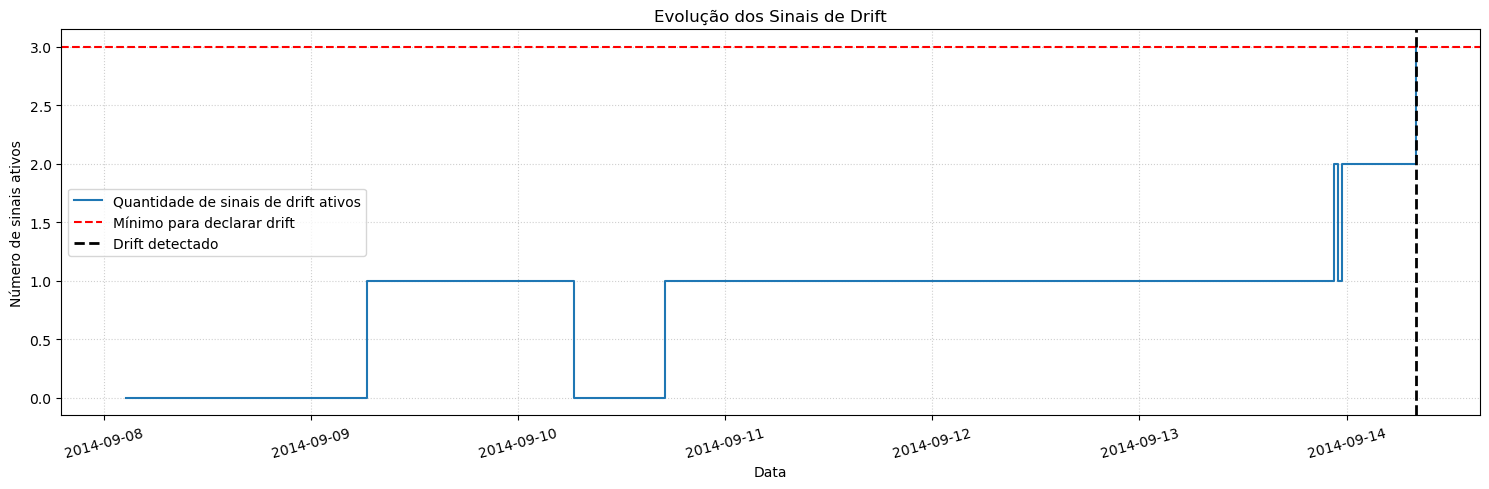

In [103]:
# Quantidade de sinais ativos
plt.figure(figsize=(15, 5))

plt.step(
    df_monitoramento['ds'],
    df_monitoramento['qtd_sinais_drift'],
    where='post',
    label='Quantidade de sinais de drift ativos'
)

plt.axhline(
    min_drift_signals,
    color='red',
    linestyle='--',
    label='Mínimo para declarar drift'
)

if drift_detectado:
    plt.axvline(
        drift_timestamp,
        color='black',
        linestyle='--',
        linewidth=2,
        label='Drift detectado'
    )

plt.title('Evolução dos Sinais de Drift')
plt.xlabel('Data')
plt.ylabel('Número de sinais ativos')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

#### Evolução do Drift
Aqui conseguimos acompanhar quantos sinais foram disparandos ao longo do tempo até atingirmos 3 alertas que aponta um drift que é necessário o ajusto do modelo, interessante notar que em alguns momentos um sinal para de aptar o que reforça que analisar mais de um aspecto é importante para esses casos.

In [ ]:
if drift_detectado:
    resumo_drift = df_monitoramento_completo[df_monitoramento_completo['drift_detectado']].iloc[0]

    print("Resumo do drift detectado")
    print("-------------------------")
    print(f"Data/hora: {resumo_drift['ds']}")
    print(f"Posição no stream: {int(resumo_drift['posicao_stream'])}")
    print(f"Medições até o drift: {int(resumo_drift['posicao_stream']) + 1}")
    print(f"Valor real: {resumo_drift['y']:.2f}")
    print(f"Valor previsto: {resumo_drift['yhat']:.2f}")
    print(f"Erro: {resumo_drift['erro']:.2f}")
    print(f"MAE móvel: {resumo_drift['mae_movel']:.2f}")
    print(f"Taxa de anomalias móvel: {resumo_drift['taxa_anomalia_movel']:.4f}")
    print(f"STD resíduos móvel: {resumo_drift['std_residuos_movel']:.2f}")
    print(f"p-value KS: {resumo_drift['ks_p_value']}")
    print(f"Sinais ativos: {int(resumo_drift['qtd_sinais_drift'])}")
else:
    print("Nenhum drift foi detectado no período simulado.")

Resumo do drift detectado
-------------------------
Data/hora: 2014-09-14 08:00:00
Posição no stream: 1840
Medições até o drift: 1841
Valor real: 7725.00
Valor previsto: 7607.14
Erro: 117.86
MAE móvel: 1221.63
Taxa de anomalias móvel: 0.0625
STD resíduos móvel: 1493.68
p-value KS: 0.004318329002513199
Sinais ativos: 3


Após o treinamento do modelo inicial por mínimos quadrados, foi simulada a chegada sequencial dos dados em formato de stream. Para cada nova observação, o modelo gerava uma previsão e o erro era calculado em relação ao valor observado. Em seguida, foram avaliadas métricas em janelas móveis, incluindo MAE, taxa de anomalias, volatilidade dos resíduos e mudança na distribuição dos erros por meio do teste Kolmogorov-Smirnov. O drift foi declarado quando pelo menos três dessas métricas indicaram degradação simultaneamente.

## 04 - Retreinamento do modelo com mínimos quadrados ponderados

Nesta etapa, o modelo é retreinado após a identificação de sinais de degradação no desempenho.  
Diferente do OLS tradicional, o retreinamento utiliza Mínimos Quadrados Ponderados, atribuindo pesos diferentes às observações.  
O objetivo é reduzir a influência de pontos com erros muito altos, que podem representar anomalias ou ruído.  
Assim, o novo modelo tende a se ajustar melhor ao comportamento predominante da série e se tornar mais estável.

In [104]:
# print de quantos pontos foram avaliados até o drift e a data em que aconteceu
linha_drift_ols = df_monitoramento_completo[df_monitoramento_completo['drift_detectado'] == True].iloc[0]

drift_timestamp_ols = linha_drift_ols['ds']
pos_drift_ols = int(linha_drift_ols['posicao_stream'])

print(f"Drift OLS detectado em: {drift_timestamp_ols}")
print(f"Posição no stream: {pos_drift_ols}")

Drift OLS detectado em: 2014-09-14 08:00:00
Posição no stream: 1840


In [106]:
# para termos uma certa justiça vamos usar um dataset do mesmo tamanho do usado no treinamento anterior
# e para simular o mundo real vamos usar para treinamento os dados avaliados pelo primeiro modelo
window_retrain = len(df_treino_model1)

df_retreino_wls = df_stream.iloc[
    max(0, pos_drift_ols - window_retrain):pos_drift_ols
].copy()

df_retreino_wls.shape

(1483, 14)

In [108]:
# definição do dataset de calibração 2
df_calibracao_model2 = df_stream[window_retrain:].copy()
df_calibracao_model2.shape

(389, 14)

Vamos aplicar modelo OLS original sobre a base que será usada no retreinamento.

A previsão gerada pelo modelo antigo é armazenada em `yhat_ols`, permitindo comparar o comportamento esperado pelo modelo anterior com os valores reais.

Em seguida, são calculados o erro e o erro absoluto do OLS nessa nova janela.

Esses erros serão usados como referência para definir os pesos do modelo ponderado, reduzindo a influência de observações com erros muito elevados.

In [109]:
# calculo dos erros e definições dos pesos
df_retreino_wls['yhat_ols'] = ols.predict(df_retreino_wls[features])
df_retreino_wls['erro_ols'] = df_retreino_wls['y'] - df_retreino_wls['yhat_ols']
df_retreino_wls['abs_erro_ols'] = df_retreino_wls['erro_ols'].abs()

In [110]:
# Padroniza o erro absoluto do OLS pela sua variabilidade histórica, criando uma medida relativa do tamanho do erro
std_erro = df_retreino_wls['erro_ols'].std()

df_retreino_wls['erro_padronizado'] = (
    df_retreino_wls['abs_erro_ols'] / std_erro
)

In [111]:
# Define os pesos do WLS, reduzindo a influência das observações com maior erro padronizado
df_retreino_wls['peso_wls'] = (
    1 / (1 + df_retreino_wls['erro_padronizado'])
)

In [142]:
# peso mínimo e máximo que será usado
df_retreino_wls['peso_wls'].min(),df_retreino_wls['peso_wls'].max()

(np.float64(0.14036425691828391), np.float64(0.99765762921309))

In [143]:
class WeightedLeastSquares:
    """
    Implementação manual de Mínimos Quadrados Ponderados.

    O modelo resolve:

        beta = (X.T W X)^(-1) X.T W y

    onde:
        X = matriz de features
        y = variável resposta
        W = matriz diagonal de pesos

    Na prática, para evitar construir W explicitamente, usamos:

        X_ponderado = sqrt(W) * X
        y_ponderado = sqrt(W) * y

    e resolvemos um problema OLS tradicional sobre os dados ponderados.
    """

    def __init__(self, fit_intercept=True, ridge_eps=0.0):
        """
        Inicializa o modelo.

        Parâmetros
        ----------
        fit_intercept : bool
            Se True, adiciona uma coluna de 1s em X para estimar o intercepto.

        ridge_eps : float
            Pequena regularização opcional adicionada na diagonal de X.T @ W @ X.
            Útil para evitar erro quando a matriz é singular ou quase singular.
            Se ridge_eps = 0.0, não aplica regularização.
        """

        self.fit_intercept = fit_intercept
        self.ridge_eps = ridge_eps

        # Coeficientes das variáveis explicativas, sem o intercepto
        self.coef_ = None

        # Intercepto do modelo
        self.intercept_ = None

        # Vetor completo de coeficientes.
        # Se fit_intercept=True:
        # beta_[0] = intercepto
        # beta_[1:] = coeficientes das features
        self.beta_ = None

    def _add_intercept(self, X):
        """
        Prepara a matriz X.

        Etapas:
        1. Converte X para array NumPy do tipo float.
        2. Se X vier como vetor 1D, transforma em matriz coluna.
        3. Se fit_intercept=True, adiciona uma coluna de 1s à esquerda.

        Exemplo:
            X original:
                [[10],
                 [20],
                 [30]]

            X com intercepto:
                [[1, 10],
                 [1, 20],
                 [1, 30]]
        """

        # Garante que X seja um array NumPy numérico
        X = np.asarray(X, dtype=float)

        # Se X for uma única feature em formato 1D,
        # transforma para matriz de dimensão n x 1
        if X.ndim == 1:
            X = X.reshape(-1, 1)

        # Adiciona coluna de 1s para representar o intercepto
        if self.fit_intercept:
            ones = np.ones((X.shape[0], 1))
            X = np.hstack([ones, X])

        return X

    def fit(self, X, y, sample_weight):
        """
        Ajusta o modelo de Mínimos Quadrados Ponderados.

        Parâmetros
        ----------
        X : array-like
            Matriz de variáveis explicativas.

        y : array-like
            Vetor da variável resposta.

        sample_weight : array-like
            Peso de cada observação.

            Quanto maior o peso, mais aquela linha influencia o ajuste.
            Quanto menor o peso, menos aquela linha influencia o ajuste.

            Em WLS, a função objetivo é:

                soma_i w_i * (y_i - yhat_i)^2

        Retorno
        -------
        self
            Retorna o próprio objeto ajustado.
        """

        # ============================================================
        # 1. Preparar X e y
        # ============================================================

        # Adiciona intercepto, se necessário
        X_design = self._add_intercept(X)

        # Converte y para array coluna, com dimensão n x 1
        y = np.asarray(y, dtype=float).reshape(-1, 1)

        # Converte os pesos para array coluna, com dimensão n x 1
        sample_weight = np.asarray(sample_weight, dtype=float).reshape(-1, 1)

        # ============================================================
        # 2. Validações básicas
        # ============================================================

        # X, y e pesos precisam ter o mesmo número de linhas
        if X_design.shape[0] != y.shape[0]:
            raise ValueError(
                "X e y precisam ter o mesmo número de observações."
            )

        if X_design.shape[0] != sample_weight.shape[0]:
            raise ValueError(
                "X e sample_weight precisam ter o mesmo número de observações."
            )

        # Pesos negativos não fazem sentido em WLS
        if np.any(sample_weight < 0):
            raise ValueError(
                "sample_weight não pode conter valores negativos."
            )

        # Se todos os pesos forem zero, o modelo não tem informação para aprender
        if np.all(sample_weight == 0):
            raise ValueError(
                "Todos os pesos são zero. O modelo não pode ser ajustado."
            )

        # ============================================================
        # 3. Aplicar a ponderação
        # ============================================================

        # Em vez de montar a matriz diagonal W, usamos sqrt(w).
        #
        # Isso transforma:
        #
        #     min soma_i w_i * erro_i^2
        #
        # em:
        #
        #     min soma_i (sqrt(w_i) * erro_i)^2
        #
        # Ou seja, resolvemos OLS nos dados transformados.
        sqrt_w = np.sqrt(sample_weight)

        # Cada linha de X é multiplicada pela raiz do peso daquela observação
        X_weighted = X_design * sqrt_w

        # Cada valor de y também é multiplicado pela raiz do peso
        y_weighted = y * sqrt_w

        # ============================================================
        # 4. Montar as equações normais ponderadas
        # ============================================================

        # Matriz do lado esquerdo:
        #
        #     X_weighted.T @ X_weighted
        #
        # que é equivalente a:
        #
        #     X.T @ W @ X
        XtWX = X_weighted.T @ X_weighted

        # Vetor do lado direito:
        #
        #     X_weighted.T @ y_weighted
        #
        # que é equivalente a:
        #
        #     X.T @ W @ y
        XtWy = X_weighted.T @ y_weighted

        # ============================================================
        # 5. Regularização opcional
        # ============================================================

        # Se ridge_eps > 0, adicionamos um pequeno valor na diagonal.
        #
        # Isso ajuda quando XtWX é singular ou quase singular.
        #
        # Exemplo:
        #     XtWX + 1e-8 * I
        #
        # Observação:
        #     Isso já vira uma pequena versão de Ridge ponderado.
        if self.ridge_eps > 0:
            XtWX = XtWX + self.ridge_eps * np.eye(XtWX.shape[0])

        # ============================================================
        # 6. Resolver o sistema linear
        # ============================================================

        # Resolve:
        #
        #     XtWX @ beta = XtWy
        #
        # Em vez de calcular:
        #
        #     beta = inv(XtWX) @ XtWy
        #
        # usar np.linalg.solve é numericamente melhor.
        beta = np.linalg.solve(XtWX, XtWy)

        # ============================================================
        # 7. Salvar coeficientes aprendidos
        # ============================================================

        # Transforma beta de matriz coluna para vetor 1D
        self.beta_ = beta.flatten()

        # Se há intercepto, o primeiro elemento de beta é o intercepto
        if self.fit_intercept:
            self.intercept_ = self.beta_[0]
            self.coef_ = self.beta_[1:]

        # Se não há intercepto, todos os betas são coeficientes
        else:
            self.intercept_ = 0.0
            self.coef_ = self.beta_

        return self

    def predict(self, X):
        """
        Gera predições usando os coeficientes ajustados.

        Parâmetros
        ----------
        X : array-like
            Matriz de variáveis explicativas.

        Retorno
        -------
        array
            Vetor com as predições.
        """

        # ============================================================
        # 1. Verificar se o modelo já foi treinado
        # ============================================================

        if self.beta_ is None:
            raise ValueError(
                "O modelo ainda não foi ajustado. Execute .fit() antes de .predict()."
            )

        # ============================================================
        # 2. Preparar X no mesmo formato usado no treino
        # ============================================================

        X_design = self._add_intercept(X)

        # ============================================================
        # 3. Aplicar a equação yhat = X @ beta
        # ============================================================

        y_pred = X_design @ self.beta_.reshape(-1, 1)

        # Retorna como vetor 1D
        return y_pred.flatten()

In [144]:
# definindo features, target e pesos
X_retrain = df_retreino_wls[features]
y_retrain = df_retreino_wls['y']
weights = df_retreino_wls['peso_wls']

In [116]:
# Inicializa o modelo de Mínimos Quadrados Ponderados com intercepto e pequena regularização para maior estabilidade numérica
wls = WeightedLeastSquares(
    fit_intercept=True,
    ridge_eps=1e-8
)

In [145]:
# Treina o modelo WLS usando os pesos calculados e exibe os parâmetros ajustados
wls.fit(
    X=X_retrain,
    y=y_retrain,
    sample_weight=weights
)

print("Intercepto:", wls.intercept_)
print("Coeficientes:", wls.coef_)

Intercepto: 1336.1328388194709
Coeficientes: [ 1.81476314e+00  4.05440479e-02 -1.28569667e-01  6.90419963e-01
  1.91817941e-01 -1.70012284e+00 -4.25739188e+02 -2.17198266e+02
 -1.82203450e+01 -1.31112733e+02]


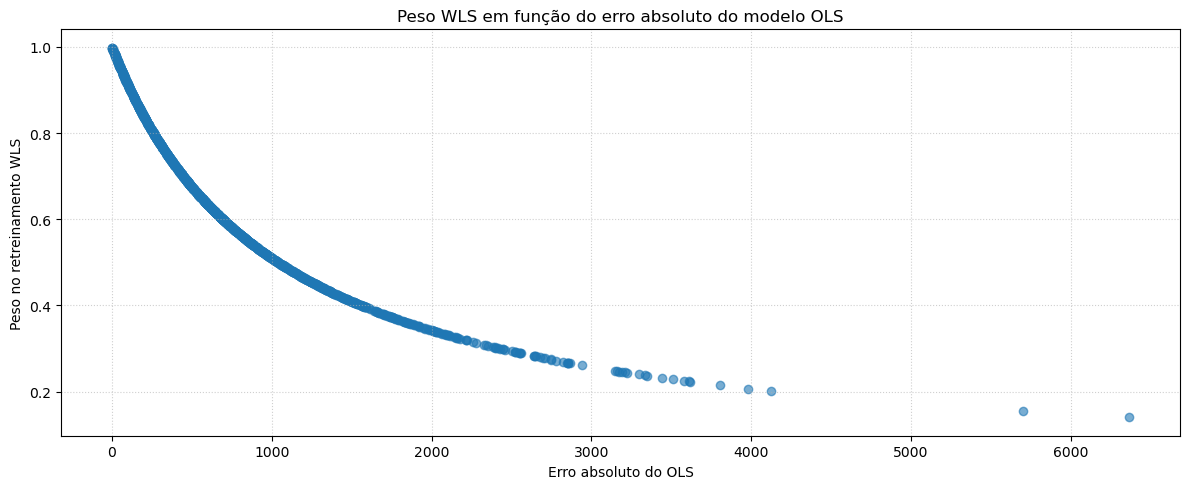

In [146]:
# Gráfico para visualizarmos que quanto maior o erro absoluto do OLS, menor será o peso da observação no retreinamento WLS
plt.figure(figsize=(12, 5))

plt.scatter(
    df_retreino_wls['abs_erro_ols'],
    df_retreino_wls['peso_wls'],
    alpha=0.6
)

plt.title('Peso WLS em função do erro absoluto do modelo OLS')
plt.xlabel('Erro absoluto do OLS')
plt.ylabel('Peso no retreinamento WLS')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

### Retreinamento com mínimos quadrados ponderados

Após a detecção de drift, o modelo foi retreinado utilizando mínimos quadrados ponderados.

Diferentemente do OLS, em que todas as observações possuem o mesmo peso, no WLS cada ponto recebe uma importância diferente no ajuste.

Neste trabalho, os pesos foram definidos com base no erro absoluto do modelo OLS: observações com erros maiores receberam pesos menores, reduzindo a influência de possíveis outliers.

$$w_i = \frac{1}{1 + \frac{|e_i|}{\sigma_e}}$$

Dessa forma, o modelo ponderado busca capturar o comportamento estrutural da série, evitando que eventos pontuais extremos dominem o processo de ajuste.

## 05 - Métricas após o retreinamento

In [147]:
# Aplica o modelo WLS na nova janela de calibração e calcula os erros observados
X_calib = df_calibracao_model2[features]
y_calib = df_calibracao_model2[target]

df_calibracao_model2['yhat'] = wls.predict(X_calib)
df_calibracao_model2['erro'] = df_calibracao_model2['y'] - df_calibracao_model2['yhat']
df_calibracao_model2['abs_erro'] = df_calibracao_model2['erro'].abs()

historical_errors = df_calibracao_model2['erro'].values

# Define as métricas históricas e o novo threshold de MAE para monitorar drift após o retreinamento
historical_mae_mean = mean_absolute_error(
    df_calibracao_model2['y'],
    df_calibracao_model2['yhat']
)

historical_error_std = np.std(historical_errors)

threshold_mae = historical_mae_mean + 3 * df_calibracao_model2['abs_erro'].std()

print(f"Baseline MAE histórico: {historical_mae_mean:.4f}")
print(f"Desvio padrão dos erros: {historical_error_std:.4f}")
print(f"Gatilho de Alarme MAE: {threshold_mae:.4f}")

Baseline MAE histórico: 874.6050
Desvio padrão dos erros: 1172.7804
Gatilho de Alarme MAE: 3273.8264


In [148]:
# Define os parâmetros históricos da nova calibração para calcular bandas de previsão ajustadas por dia da semana e horário
z = 2.576

df_calibracao_model2['hour'] = df_calibracao_model2['ds'].dt.hour
df_calibracao_model2['day_of_week'] = df_calibracao_model2['ds'].dt.dayofweek

std_residuo_por_periodo = (
    df_calibracao_model2
    .groupby(['day_of_week', 'hour'])['erro']
    .std()
)

std_global = df_calibracao_model2['erro'].std()

min_bandwidth = df_calibracao_model2['abs_erro'].quantile(0.99)

In [149]:
# Calcula a banda de previsão ajustada para cada observação da nova janela de calibração
df_calibracao_model2['banda_ajustada'] = df_calibracao_model2.apply(
    calcular_banda_ajustada,
    axis=1
)

# Cria os limites inferior e superior da previsão a partir da banda ajustada
df_calibracao_model2['yhat_lower'] = (
    df_calibracao_model2['yhat'] - df_calibracao_model2['banda_ajustada']
)

df_calibracao_model2['yhat_upper'] = (
    df_calibracao_model2['yhat'] + df_calibracao_model2['banda_ajustada']
)

# Identifica anomalias quando o valor real fica fora dos limites da banda de previsão
df_calibracao_model2['anomalia'] = (
    (df_calibracao_model2['y'] > df_calibracao_model2['yhat_upper']) |
    (df_calibracao_model2['y'] < df_calibracao_model2['yhat_lower'])
)

taxa_anomalia_esperada = df_calibracao_model2['anomalia'].mean()

print(f"Taxa de anomalias na calibração: {taxa_anomalia_esperada:.4f}")

Taxa de anomalias na calibração: 0.0026


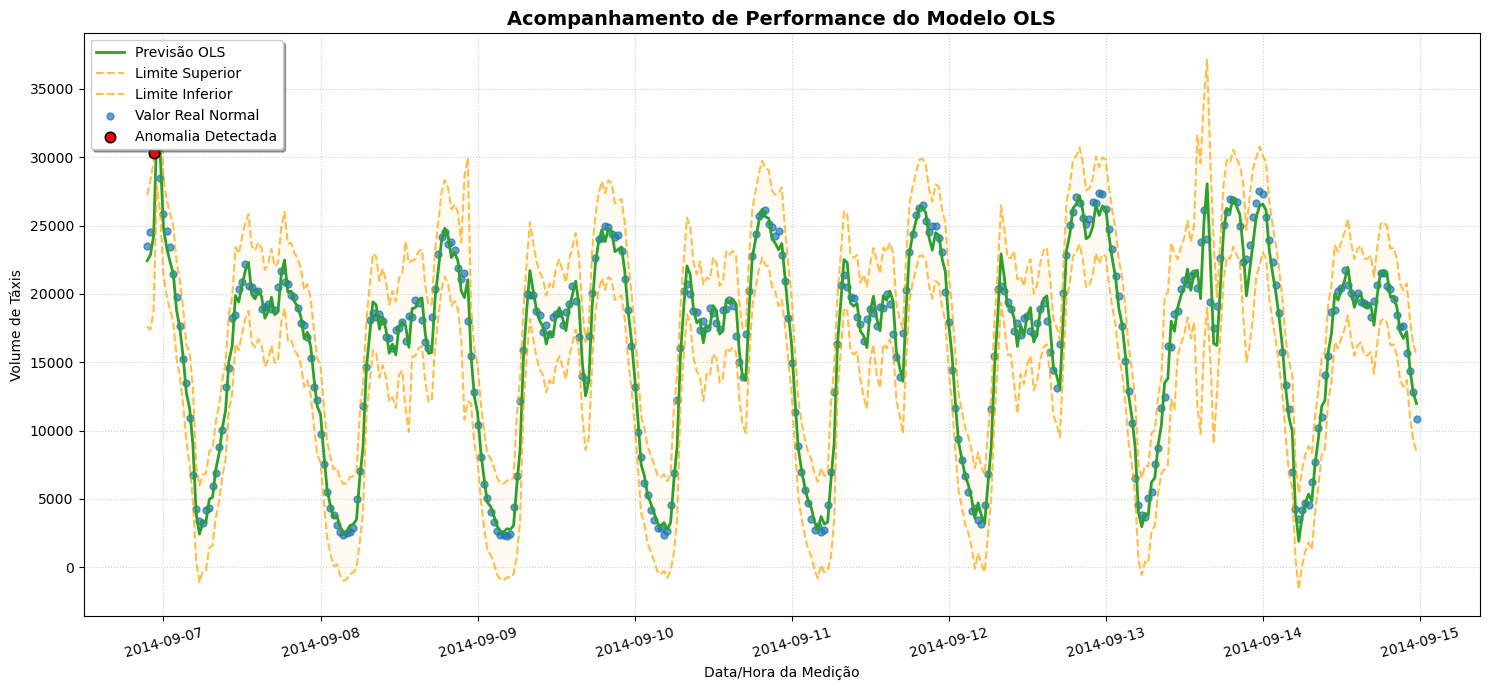

In [150]:
# plot do previsto vs o valor real no dataset de calibração
df_plot = df_calibracao_model2.copy()

df_plot['anomalia'] = (
    (df_plot['y'] > df_plot['yhat_upper'])
)

df_normal = df_plot[df_plot['anomalia'] == False]
df_anomalias = df_plot[df_plot['anomalia'] == True]

plt.figure(figsize=(15, 7))

plt.plot(
    df_plot['ds'],
    df_plot['yhat'],
    color='#2ca02c',
    linewidth=2,
    label='Previsão OLS'
)

plt.plot(
    df_plot['ds'],
    df_plot['yhat_upper'],
    color='orange',
    linestyle='--',
    alpha=0.7,
    label='Limite Superior'
)

plt.plot(
    df_plot['ds'],
    df_plot['yhat_lower'],
    color='orange',
    linestyle='--',
    alpha=0.7,
    label='Limite Inferior'
)

plt.fill_between(
    df_plot['ds'],
    df_plot['yhat_lower'],
    df_plot['yhat_upper'],
    color='orange',
    alpha=0.05
)

plt.scatter(
    df_normal['ds'],
    df_normal['y'],
    color='#1f77b4',
    s=25,
    alpha=0.7,
    label='Valor Real Normal'
)

plt.scatter(
    df_anomalias['ds'],
    df_anomalias['y'],
    color='red',
    s=55,
    marker='o',
    edgecolors='black',
    linewidths=1.2,
    zorder=5,
    label='Anomalia Detectada'
)

plt.title('Acompanhamento de Performance do Modelo OLS', fontsize=14, fontweight='bold')
plt.xlabel('Data/Hora da Medição')
plt.ylabel('Volume de Táxis')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left', frameon=True, shadow=True)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [151]:
# Erros históricos observados na janela de calibração
historical_errors = df_calibracao_model2['erro'].values
historical_abs_errors = df_calibracao_model2['abs_erro'].values

# Métricas históricas
historical_mae_mean = df_calibracao_model2['abs_erro'].mean()
historical_mae_std = df_calibracao_model2['abs_erro'].std()

historical_error_std = df_calibracao_model2['erro'].std()

# Thresholds
threshold_mae = historical_mae_mean + 3 * historical_mae_std
threshold_residual_std = historical_error_std * 1.5

# Banda aproximada de previsão usando resíduos históricos
z = 2.576  # aproximadamente 99% se assumirmos normalidade dos resíduos

df_calibracao_model2['anomalia'] = (
    (df_calibracao_model2['y'] > df_calibracao_model2['yhat_upper']) |
    (df_calibracao_model2['y'] < df_calibracao_model2['yhat_lower'])
)

taxa_anomalia_esperada = df_calibracao_model2['anomalia'].mean()

# Pode usar uma folga em relação à taxa histórica
threshold_taxa_anomalia = max(taxa_anomalia_esperada + 0.01, 0.02)

print(f"Baseline MAE histórico: {historical_mae_mean:.4f}")
print(f"Threshold MAE: {threshold_mae:.4f}")
print(f"STD histórico dos resíduos: {historical_error_std:.4f}")
print(f"Threshold volatilidade resíduos: {threshold_residual_std:.4f}")
print(f"Taxa esperada de anomalias: {taxa_anomalia_esperada:.4f}")
print(f"Threshold taxa de anomalias: {threshold_taxa_anomalia:.4f}")

Baseline MAE histórico: 874.6050
Threshold MAE: 3273.8264
STD histórico dos resíduos: 1174.2907
Threshold volatilidade resíduos: 1761.4361
Taxa esperada de anomalias: 0.0026
Threshold taxa de anomalias: 0.0200


In [152]:
df_calibracao_model2['largura_banda'] = df_calibracao_model2['yhat_upper'] - df_calibracao_model2['yhat_lower']

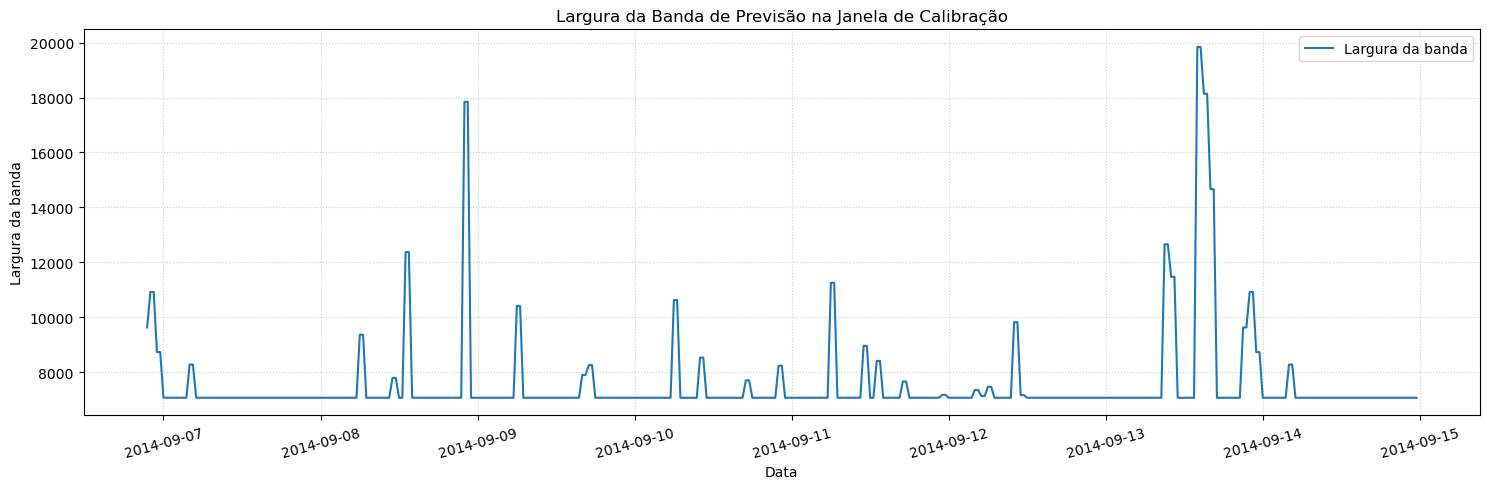

In [153]:
# plot da largura das bandas
plt.figure(figsize=(15, 5))

plt.plot(
    df_calibracao_model2['ds'],
    df_calibracao_model2['largura_banda'],
    label='Largura da banda'
)

plt.title('Largura da Banda de Previsão na Janela de Calibração')
plt.xlabel('Data')
plt.ylabel('Largura da banda')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [154]:
# Suaviza a largura da banda de previsão do modelo 2 para observar a tendência geral da incerteza na nova calibração
x = np.arange(len(df_calibracao_model2))
y_band = df_calibracao_model2['largura_banda'].values

spline = UnivariateSpline(x, y_band, s=len(x) * np.var(y_band) * 0.05)

df_calibracao_model2['largura_banda_suavizada'] = spline(x)

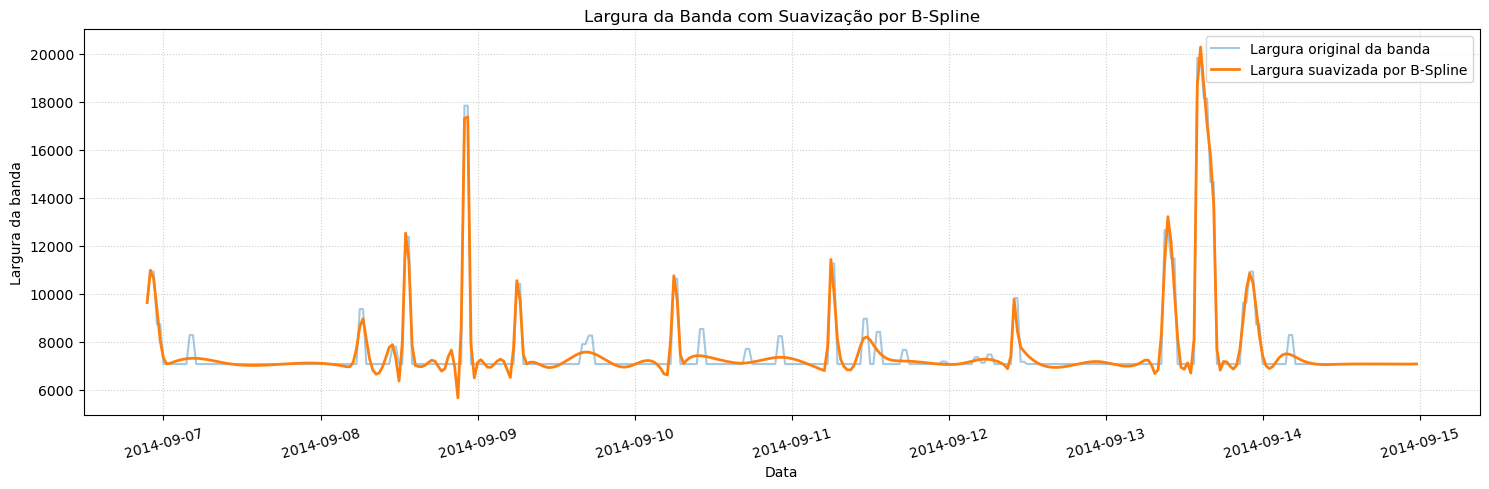

In [155]:
# plot da largura da banda vs a suavizada com B-Spline
plt.figure(figsize=(15, 5))

plt.plot(
    df_calibracao_model2['ds'],
    df_calibracao_model2['largura_banda'],
    alpha=0.4,
    label='Largura original da banda'
)

plt.plot(
    df_calibracao_model2['ds'],
    df_calibracao_model2['largura_banda_suavizada'],
    linewidth=2,
    label='Largura suavizada por B-Spline'
)

plt.title('Largura da Banda com Suavização por B-Spline')
plt.xlabel('Data')
plt.ylabel('Largura da banda')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [134]:
# Calcula quanto da largura da banda de previsão está sendo consumido pelo erro absoluto do modelo 2
df_calibracao_model2['erro_sobre_banda'] = (
    df_calibracao_model2['abs_erro'] / df_calibracao_model2['largura_banda']
)

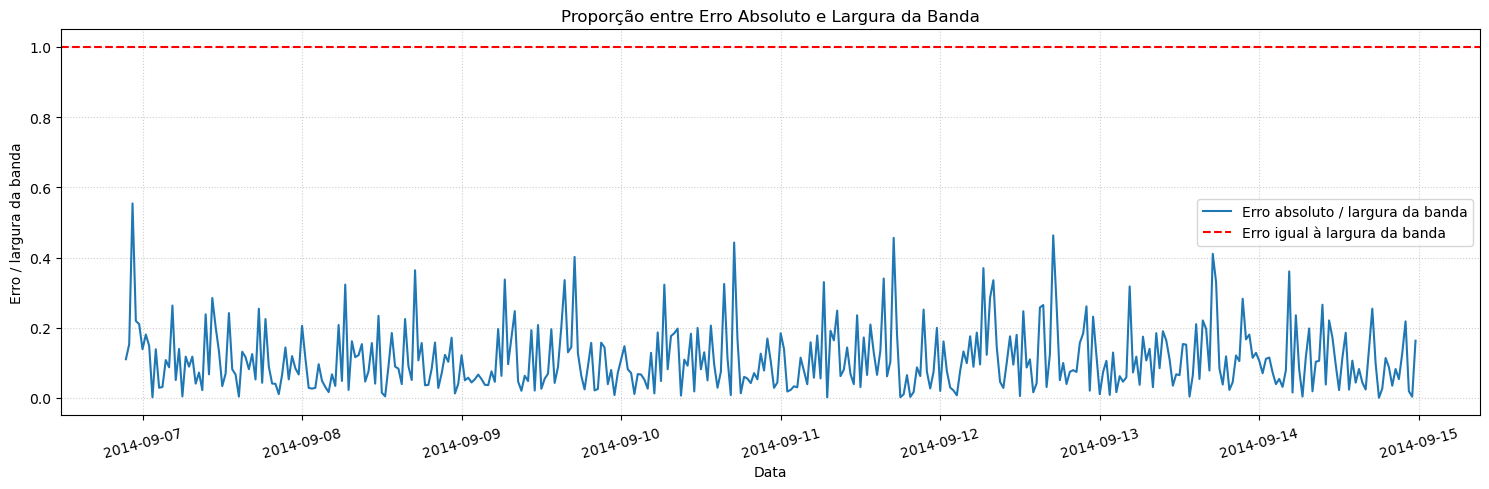

In [156]:
# Plota a proporção entre erro absoluto e largura da banda para avaliar se os erros do modelo 2 permanecem dentro da tolerância esperada
plt.figure(figsize=(15, 5))

plt.plot(
    df_calibracao_model2['ds'],
    df_calibracao_model2['erro_sobre_banda'],
    label='Erro absoluto / largura da banda'
)

plt.axhline(
    1,
    linestyle='--',
    color='red',
    label='Erro igual à largura da banda'
)

plt.title('Proporção entre Erro Absoluto e Largura da Banda')
plt.xlabel('Data')
plt.ylabel('Erro / largura da banda')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [157]:
limite_largura_banda = df_calibracao_model2['largura_banda_suavizada'].mean()
limite_largura_banda_std = df_calibracao_model2['largura_banda_suavizada'].std()
print(f'Media das larguras das bandas: {limite_largura_banda}')
print(f'STD das larguras das bandas: {limite_largura_banda_std}')

Media das larguras das bandas: 7598.336872791412
STD das larguras das bandas: 1690.2549599528854


### 06 - Previsão de novos casos até o drift do modelo (Resimulação)

In [158]:
df_stream2 = df[
    (df.ds >= '2014-09-15') &
    (df.ds < '2015-01-15')
].copy()

In [159]:
df_stream2.drop(columns='anomalies', inplace=True)

In [161]:
stream_timestamps = []
stream_errors = []
stream_maes = []
anomaly_flags = []
real_value = []
valor_previsto = []
limite_inferior = []
limite_superior = []
stream_bandwidths = []
largura_banda_atual_list = []
media_largura_banda_recente_list = []


monitoramento = []

window_size = 48 # as medições são feitas a cada 30 minutos usar 48 siginifica trabalhar com as últimas 24 horas
ks_window_size = 96 # Para medição do p-value entre distribuição vamos usar 96 que equivale à 2 dias
min_drift_signals = 3 # a simulação para se tivermos 3 ou mais sinais de drift

print("Iniciando simulação de streaming com modelo OLS...")

drift_detectado = False
drift_timestamp = None
drift_index = None

for pos, (_, row) in enumerate(df_stream2.iterrows()):

    flag_anomalia = 0
    flag_distribuicao_erro = 0
    flag_volatilidade = 0
    flag_mae = 0
    flag_banda = 0

    # 1. Predição do ponto atual com OLS
    current_df = pd.DataFrame([row])

    X_current = current_df[features]

    y_real = row['y']
    y_hat = wls.predict(X_current)[0]

    # 2. Banda de previsão baseada nos resíduos históricos
    banda_ajustada = calcular_banda_ajustada(row)

    y_lower = y_hat - banda_ajustada
    y_upper = y_hat + banda_ajustada
    largura_banda_atual = y_upper - y_lower

    # 3. Cálculo do erro
    error = y_real - y_hat
    abs_error = abs(error)

    stream_timestamps.append(row['ds'])
    stream_errors.append(float(error))
    real_value.append(y_real)
    valor_previsto.append(y_hat)
    limite_inferior.append(y_lower)
    limite_superior.append(y_upper)
    stream_bandwidths.append(largura_banda_atual)


    # 4. Anomalia pontual
    is_anomaly = 1 if (y_real > y_upper) else 0# or (y_real < y_lower)) else 0
    anomaly_flags.append(is_anomaly)

    # 5. MAE em janela móvel
    recent_errors = stream_errors[-window_size:]
    recent_abs_errors = np.abs(recent_errors)
    current_mae = np.mean(recent_abs_errors)
    stream_maes.append(current_mae)

    if len(recent_errors) >= window_size:
        if current_mae > threshold_mae:
            flag_mae = 1

    # 6. Taxa de anomalias em janela móvel
    recent_anomalies = anomaly_flags[-window_size:]
    taxa_anomalia_movel = np.mean(recent_anomalies)

    if len(recent_anomalies) >= window_size:
        if taxa_anomalia_movel > threshold_taxa_anomalia:
            flag_anomalia = 1

    # 7. Volatilidade dos resíduos em janela móvel
    std_residuos_movel = np.std(recent_errors)

    if len(recent_errors) >= window_size:
        if std_residuos_movel > threshold_residual_std:
            flag_volatilidade = 1

    # 8. KS-Test para comparar distribuição de erros
    ks_p_value = np.nan
    ks_stat = np.nan

    if len(stream_errors) >= ks_window_size and pos % 20 == 0:
        erros_recentes_ks = stream_errors[-ks_window_size:]

        ks_stat, ks_p_value = ks_2samp(
            historical_errors,
            erros_recentes_ks
        )

        if ks_p_value <= 0.05:
            flag_distribuicao_erro = 1

    # 9. Largura das bandas
    recent_bandwidths = stream_bandwidths[-window_size:]

    if len(recent_bandwidths) >= window_size:
        x_recent = np.arange(len(recent_bandwidths))
        y_recent = np.array(recent_bandwidths)

        s_base = len(y_recent) * np.var(y_recent) * 5

        s_floor = len(y_recent) * (0.05 * np.mean(np.abs(y_recent))) ** 2
        
        s_spline = max(s_base, s_floor, 1.0)
        
        spline_largura_banda_recente = UnivariateSpline(
            x_recent,
            y_recent,
            s=s_spline,
            k=3
        )

        largura_banda_suavizada_recente = spline_largura_banda_recente(x_recent)

        media_largura_banda_recente = np.mean(largura_banda_suavizada_recente)

        media_largura_banda_recente_list.append(media_largura_banda_recente)
        if media_largura_banda_recente > (limite_largura_banda+limite_largura_banda_std*3):
            flag_banda = 1

    # 10. Somatória dos sinais de drift
    qtd_sinais_drift = (
        flag_mae +
        flag_anomalia +
        flag_volatilidade +
        flag_distribuicao_erro +
        flag_banda
    )

    drift_na_linha = qtd_sinais_drift >= min_drift_signals

    # 11. Guardar resultado do monitoramento
    monitoramento.append({
        'posicao_stream': pos,
        'ds': row['ds'],
        'y': y_real,
        'yhat': y_hat,
        'yhat_lower': y_lower,
        'yhat_upper': y_upper,
        'erro': error,
        'abs_erro': abs_error,
        'mae_movel': current_mae,
        'std_residuos_movel': std_residuos_movel,
        'taxa_anomalia_movel': taxa_anomalia_movel,
        'ks_stat': ks_stat,
        'ks_p_value': ks_p_value,
        'largura_banda': largura_banda_atual,
        'media_largura_banda_suavizada': media_largura_banda_recente,
        'flag_mae': flag_mae,
        'flag_anomalia': flag_anomalia,
        'flag_volatilidade': flag_volatilidade,
        'flag_distribuicao_erro': flag_distribuicao_erro,
        'flag_banda': flag_banda,
        'qtd_sinais_drift': qtd_sinais_drift,
        'drift_detectado': drift_na_linha
    })

    # 12. Condição de parada
    if drift_na_linha:
        drift_detectado = True
        drift_timestamp = row['ds']
        drift_index = pos

        print("Drift detectado! Parando simulação.")
        print(f"Data/hora do drift: {drift_timestamp}")
        print(f"Medições até o drift: {pos + 1}")
        print(f"Quantidade de sinais ativos: {qtd_sinais_drift}")

        if flag_mae:
            print("- MAE degradado")
        if flag_anomalia:
            print("- Taxa de anomalias acima do esperado")
        if flag_volatilidade:
            print("- Volatilidade dos resíduos elevada")
        if flag_distribuicao_erro:
            print("- Distribuição dos erros diferente da calibração")
        if flag_banda:
            print("- Aumento das bandas de previsão")

        break

if qtd_sinais_drift < 3:
    print('Stream Finalizado, não houve drift')

df_monitoramento = pd.DataFrame(monitoramento)

Iniciando simulação de streaming com modelo OLS...
Stream Finalizado, não houve drift


In [162]:
df_monitoramento_completo = df_monitoramento.copy()
df_monitoramento = df_monitoramento[-300:]

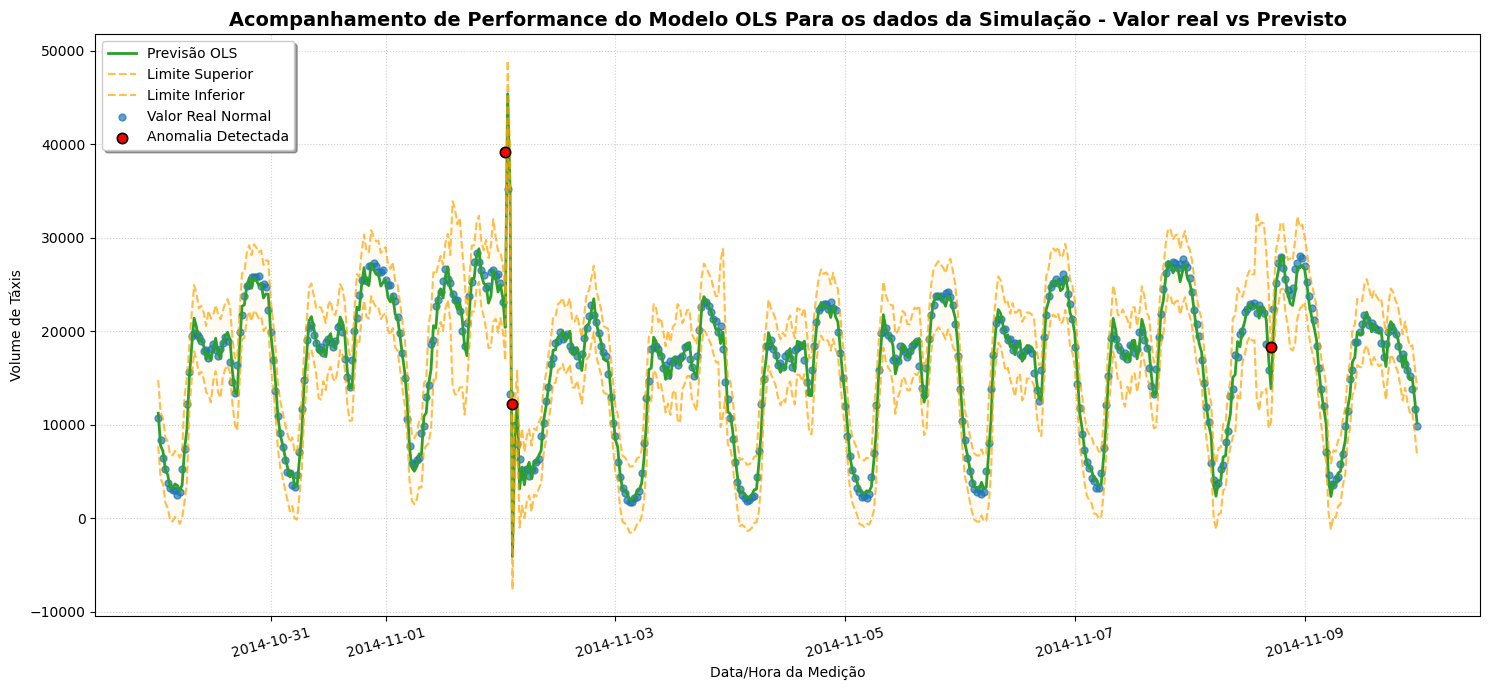

In [163]:
df_plot = df_monitoramento_completo[(df_monitoramento_completo.ds > '2014-10-30') & (df_monitoramento_completo.ds < '2014-11-10')].copy()

df_plot['anomalia'] = (
    (df_plot['y'] > df_plot['yhat_upper'])
)

df_normal = df_plot[df_plot['anomalia'] == False]
df_anomalias = df_plot[df_plot['anomalia'] == True]

plt.figure(figsize=(15, 7))

plt.plot(
    df_plot['ds'],
    df_plot['yhat'],
    color='#2ca02c',
    linewidth=2,
    label='Previsão OLS'
)

plt.plot(
    df_plot['ds'],
    df_plot['yhat_upper'],
    color='orange',
    linestyle='--',
    alpha=0.7,
    label='Limite Superior'
)

plt.plot(
    df_plot['ds'],
    df_plot['yhat_lower'],
    color='orange',
    linestyle='--',
    alpha=0.7,
    label='Limite Inferior'
)

plt.fill_between(
    df_plot['ds'],
    df_plot['yhat_lower'],
    df_plot['yhat_upper'],
    color='orange',
    alpha=0.05
)

plt.scatter(
    df_normal['ds'],
    df_normal['y'],
    color='#1f77b4',
    s=25,
    alpha=0.7,
    label='Valor Real Normal'
)

plt.scatter(
    df_anomalias['ds'],
    df_anomalias['y'],
    color='red',
    s=55,
    marker='o',
    edgecolors='black',
    linewidths=1.2,
    zorder=5,
    label='Anomalia Detectada'
)

plt.title('Acompanhamento de Performance do Modelo OLS Para os dados da Simulação - Valor real vs Previsto', fontsize=14, fontweight='bold')
plt.xlabel('Data/Hora da Medição')
plt.ylabel('Volume de Táxis')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left', frameon=True, shadow=True)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

A anomalia no gráfico acima referece ao dia 02-11-2014 um dia após a maratona de NYC.

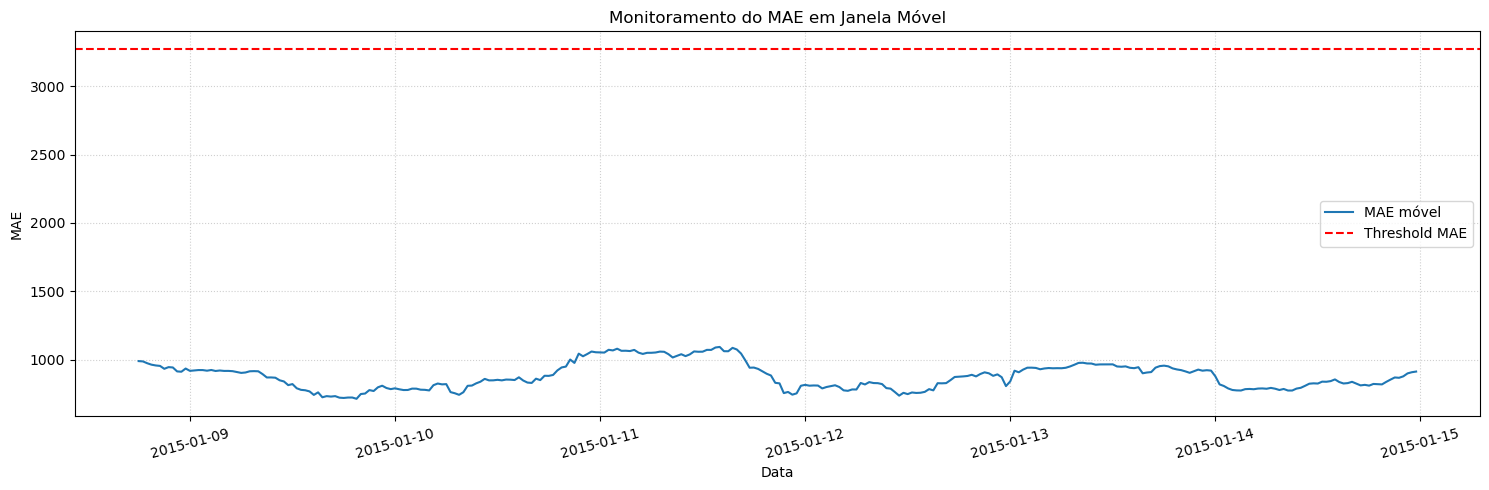

In [164]:
# MAE móvel
plt.figure(figsize=(15, 5))

plt.plot(
    df_monitoramento['ds'],
    df_monitoramento['mae_movel'],
    label='MAE móvel'
)

plt.axhline(
    threshold_mae,
    color='red',
    linestyle='--',
    label='Threshold MAE'
)

if drift_detectado:
    plt.axvline(
        drift_timestamp,
        color='black',
        linestyle='--',
        linewidth=2,
        label='Drift detectado'
    )

plt.title('Monitoramento do MAE em Janela Móvel')
plt.xlabel('Data')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

#### MAE

A métrica de MAE permanece relativamente estável ao longo do stream, oscilando pontualmente acima de `1000`, mas sem apresentar uma tendência clara de crescimento contínuo.

Esse comportamento indica que o modelo retreinado com Mínimos Quadrados Ponderados está mais estável em relação ao modelo OLS original.

Enquanto no primeiro modelo o aumento progressivo do MAE evidenciava degradação de desempenho, no modelo WLS os erros médios se mantêm mais controlados ao longo do tempo.

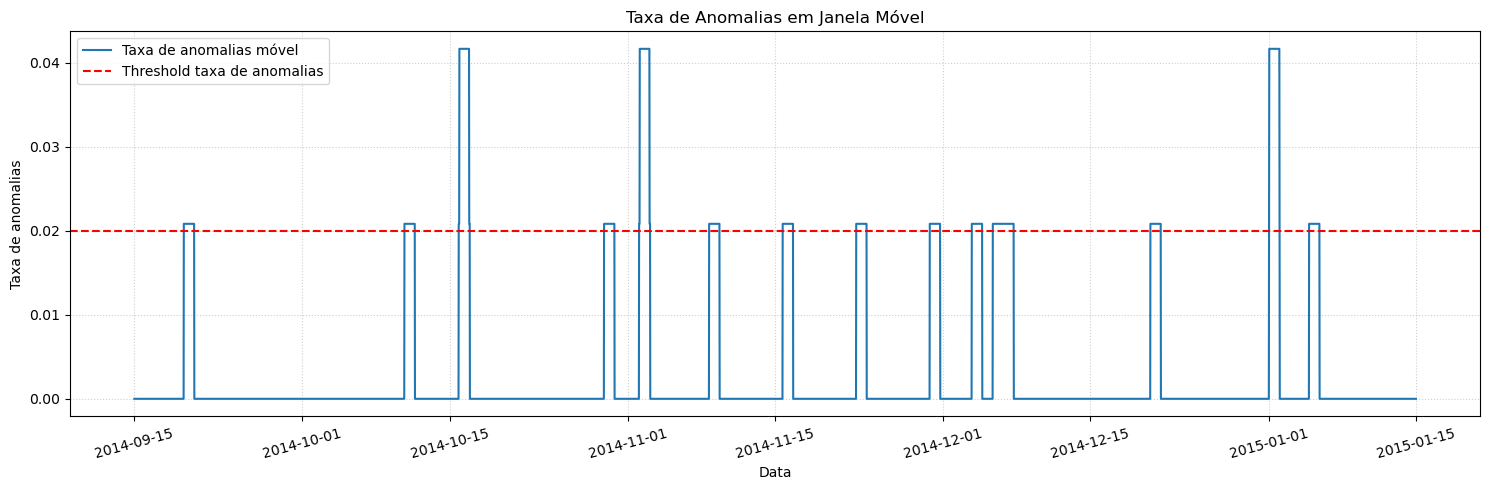

In [165]:
# Taxa móvel de anomalias
plt.figure(figsize=(15, 5))

plt.plot(
    df_monitoramento_completo['ds'],
    df_monitoramento_completo['taxa_anomalia_movel'],
    label='Taxa de anomalias móvel'
)

plt.axhline(
    threshold_taxa_anomalia,
    color='red',
    linestyle='--',
    label='Threshold taxa de anomalias'
)

if drift_detectado:
    plt.axvline(
        drift_timestamp,
        color='black',
        linestyle='--',
        linewidth=2,
        label='Drift detectado'
    )

plt.title('Taxa de Anomalias em Janela Móvel')
plt.xlabel('Data')
plt.ylabel('Taxa de anomalias')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

#### Taxa móvel de anomalias

No primeiro modelo, a degradação foi mais evidente, com a taxa móvel de anomalias chegando a aproximadamente `12%`.

Após o retreinamento com Mínimos Quadrados Ponderados, essa taxa passa a apresentar um comportamento mais controlado, ficando apenas levemente acima do `threshold` em alguns momentos.

Mesmo nos piores casos, a taxa atinge valores próximos de `4%`, bem abaixo do observado no modelo original.

Embora superar o `threshold` ainda indique atenção, a comparação mostra que o modelo WLS apresenta maior estabilidade e menor frequência de anomalias ao longo do stream.

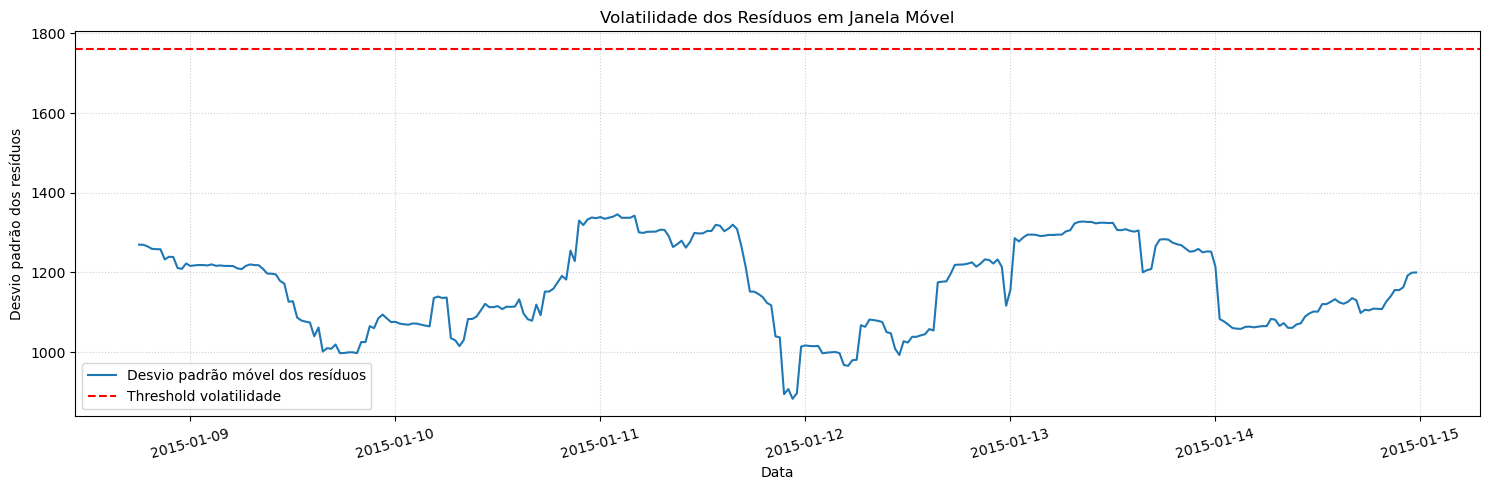

In [166]:
# Volatilidade dos resíduos
plt.figure(figsize=(15, 5))

plt.plot(
    df_monitoramento['ds'],
    df_monitoramento['std_residuos_movel'],
    label='Desvio padrão móvel dos resíduos'
)

plt.axhline(
    threshold_residual_std,
    color='red',
    linestyle='--',
    label='Threshold volatilidade'
)

if drift_detectado:
    plt.axvline(
        drift_timestamp,
        color='black',
        linestyle='--',
        linewidth=2,
        label='Drift detectado'
    )

plt.title('Volatilidade dos Resíduos em Janela Móvel')
plt.xlabel('Data')
plt.ylabel('Desvio padrão dos resíduos')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

#### Volatilidade dos resíduos

No modelo anterior, o threshold de volatilidade dos resíduos estava próximo de `1500`, enquanto no modelo atual esse limite ficou em torno de `1800`.

A principal diferença é que, no primeiro modelo, a volatilidade aumentava gradualmente até ultrapassar o valor de corte, indicando perda progressiva de estabilidade.

No modelo retreinado com WLS, a volatilidade permanece abaixo de `1500`, ficando distante do novo threshold definido.

Esse comportamento mostra que os resíduos ficaram mais estáveis, variando aproximadamente entre `500` e `1400`, sem apresentar uma tendência clara de degradação ao longo do stream.

In [168]:
# Calcula a largura da banda de previsão no monitoramento, medindo a distância entre os limites superior e inferior
df_monitoramento['largura_banda'] = (
    df_monitoramento['yhat_upper'] - df_monitoramento['yhat_lower']
)

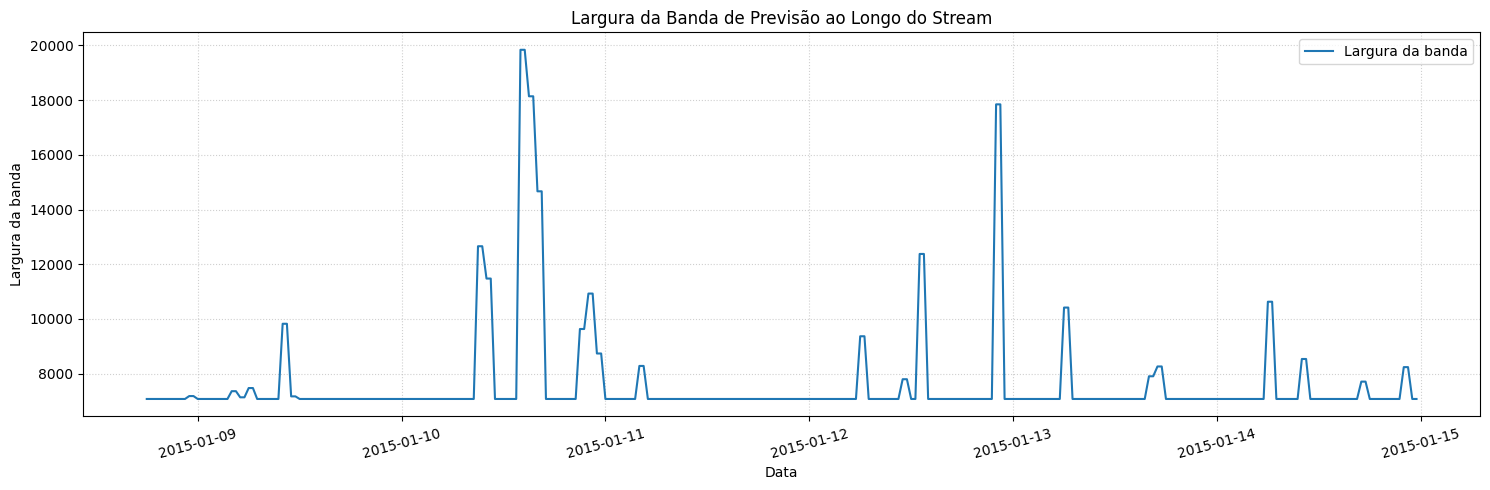

In [ ]:
plt.figure(figsize=(15, 5))

plt.plot(
    df_monitoramento['ds'],
    df_monitoramento['largura_banda'],
    label='Largura da banda'
)

if drift_detectado:
    plt.axvline(
        drift_timestamp,
        color='black',
        linestyle='--',
        linewidth=2,
        label='Drift detectado'
    )

plt.title('Largura da Banda de Previsão ao Longo do Stream')
plt.xlabel('Data')
plt.ylabel('Largura da banda')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

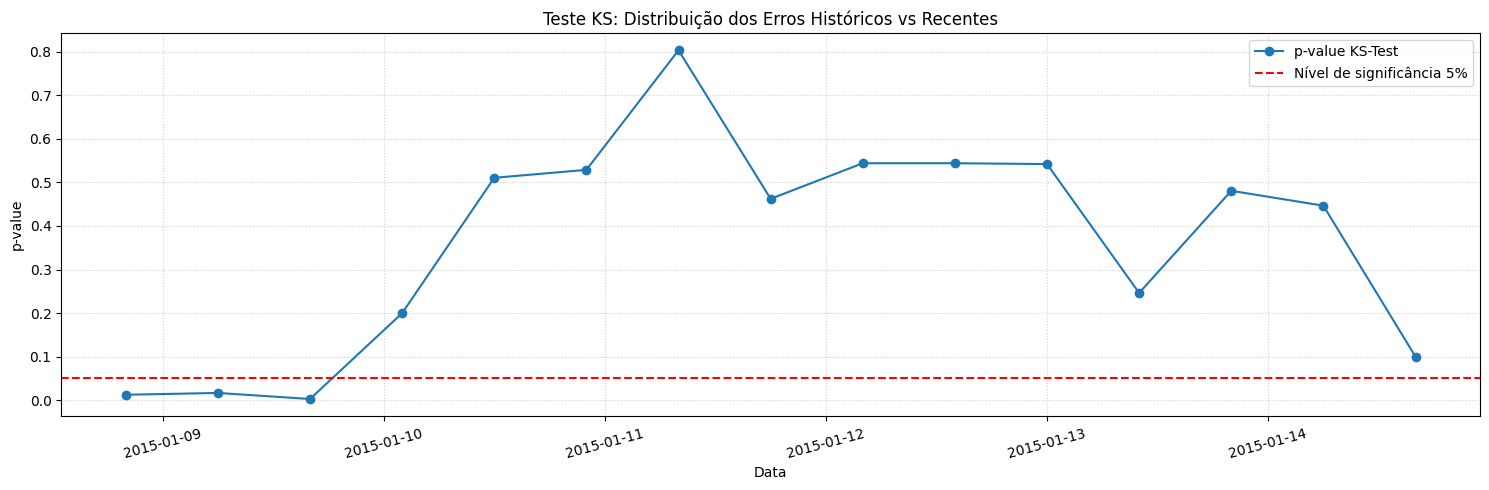

In [ ]:
# P-value do KS-Test
df_ks = df_monitoramento.dropna(subset=['ks_p_value'])

plt.figure(figsize=(15, 5))

plt.plot(
    df_ks['ds'],
    df_ks['ks_p_value'],
    marker='o',
    label='p-value KS-Test'
)

plt.axhline(
    0.05,
    color='red',
    linestyle='--',
    label='Nível de significância 5%'
)

if drift_detectado:
    plt.axvline(
        drift_timestamp,
        color='black',
        linestyle='--',
        linewidth=2,
        label='Drift detectado'
    )

plt.title('Teste KS: Distribuição dos Erros Históricos vs Recentes')
plt.xlabel('Data')
plt.ylabel('p-value')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

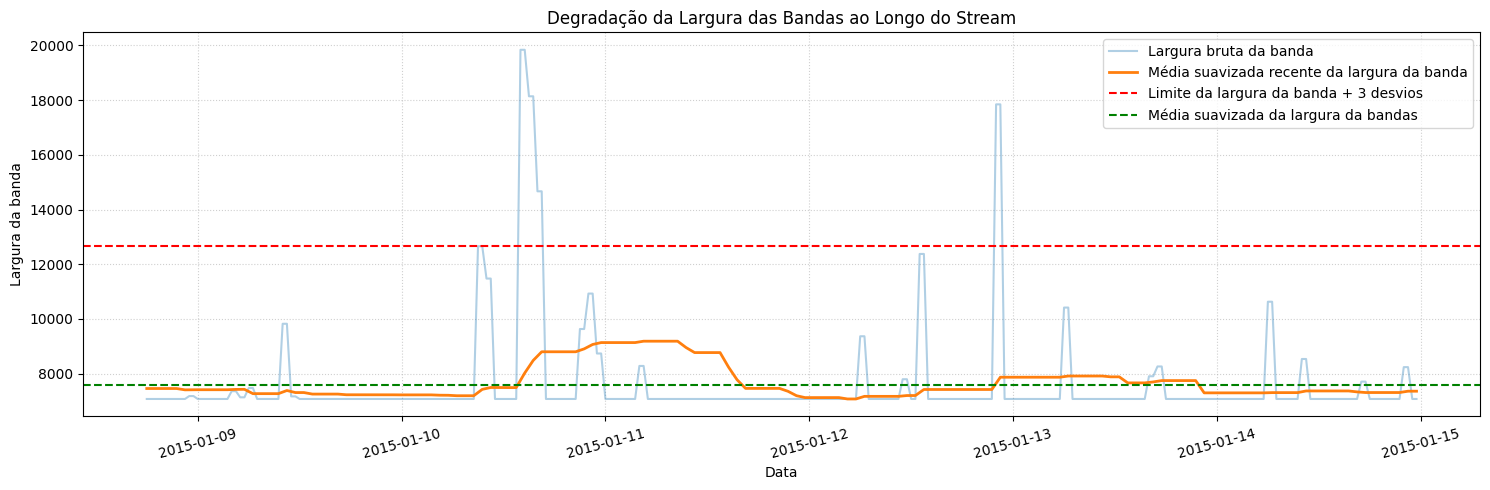

In [ ]:
plt.figure(figsize=(15, 5))

plt.plot(
    df_monitoramento['ds'],
    df_monitoramento['largura_banda'],
    alpha=0.35,
    label='Largura bruta da banda'
)

plt.plot(
    df_monitoramento['ds'],
    df_monitoramento['media_largura_banda_suavizada'],
    linewidth=2,
    label='Média suavizada recente da largura da banda'
)

plt.axhline(
    limite_largura_banda + limite_largura_banda_std * 3,
    color='red',
    linestyle='--',
    label='Limite da largura da banda + 3 desvios'
)

plt.axhline(
    limite_largura_banda,
    color='green',
    linestyle='--',
    label='Média suavizada da largura da bandas'
)

if drift_detectado:
    plt.axvline(
        drift_timestamp,
        color='black',
        linestyle='--',
        linewidth=2,
        label='Drift detectado'
    )

plt.title('Degradação da Largura das Bandas ao Longo do Stream')
plt.xlabel('Data')
plt.ylabel('Largura da banda')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Degradação da Largura das Bandas ao Longo do Stream

Agora a média suavizada até chegar em um periódo superar a média vista no teste mas depois volta a ficar abaixo circuncidado a linha verde que é a média do visto no treinamento.

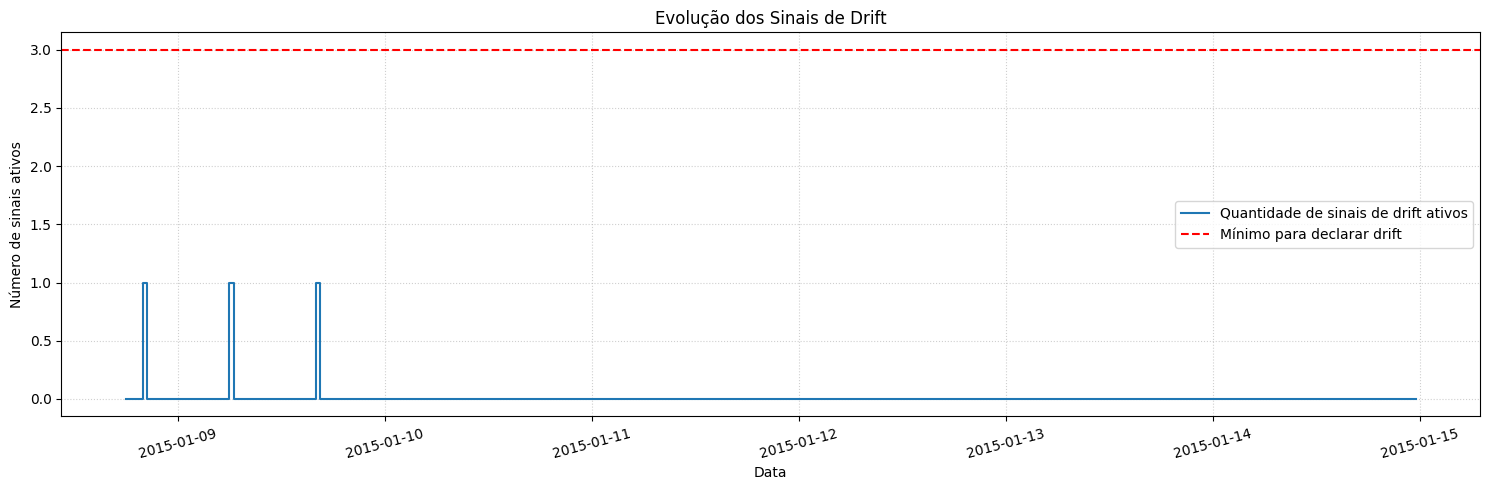

In [ ]:
# Quantidade de sinais ativos
plt.figure(figsize=(15, 5))

plt.step(
    df_monitoramento['ds'],
    df_monitoramento['qtd_sinais_drift'],
    where='post',
    label='Quantidade de sinais de drift ativos'
)

plt.axhline(
    min_drift_signals,
    color='red',
    linestyle='--',
    label='Mínimo para declarar drift'
)

if drift_detectado:
    plt.axvline(
        drift_timestamp,
        color='black',
        linestyle='--',
        linewidth=2,
        label='Drift detectado'
    )

plt.title('Evolução dos Sinais de Drift')
plt.xlabel('Data')
plt.ylabel('Número de sinais ativos')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [ ]:
if drift_detectado:
    resumo_drift = df_monitoramento_completo[df_monitoramento_completo['drift_detectado']].iloc[0]

    print("Resumo do drift detectado")
    print("-------------------------")
    print(f"Data/hora: {resumo_drift['ds']}")
    print(f"Posição no stream: {int(resumo_drift['posicao_stream'])}")
    print(f"Medições até o drift: {int(resumo_drift['posicao_stream']) + 1}")
    print(f"Valor real: {resumo_drift['y']:.2f}")
    print(f"Valor previsto: {resumo_drift['yhat']:.2f}")
    print(f"Erro: {resumo_drift['erro']:.2f}")
    print(f"MAE móvel: {resumo_drift['mae_movel']:.2f}")
    print(f"Taxa de anomalias móvel: {resumo_drift['taxa_anomalia_movel']:.4f}")
    print(f"STD resíduos móvel: {resumo_drift['std_residuos_movel']:.2f}")
    print(f"p-value KS: {resumo_drift['ks_p_value']}")
    print(f"Sinais ativos: {int(resumo_drift['qtd_sinais_drift'])}")
else:
    print("Nenhum drift foi detectado no período simulado.")
    print(f"Foram processados {len(df_monitoramento_completo)} pontos de medição")

Nenhum drift foi detectado no período simulado.


5856